# Answer BQ-01 through BQ-06

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime as dt
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from scipy import stats

%matplotlib inline

## What is the month-on-month trend in total orders and Gross Merchandise Value (GMV) over the full dataset period?

In [2]:
try:
   orders=pd.read_parquet('orders.parquet')
except Exception as e:
   print("something went wrong: " + e.message)


In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [4]:
try:
  order_items=pd.read_parquet('order_items.parquet')
except Exception as e:
  print("something went wrong: " + e.message)

In [5]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
orders_order_items=pd.merge(orders,order_items,on='order_id')

In [7]:
orders_order_items['month_year'] = orders_order_items['order_purchase_timestamp'].dt.to_period('M')

In [8]:
orders_order_items.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,month_year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,2018-02


In [9]:
month_on_month_trend=orders_order_items.groupby(['month_year']).agg({
    'order_id':'nunique','price':'sum','freight_value':'sum'
    }).rename(columns={
        'order_id':'total_orders','price':'total_price','freight_value':'total_freight_value'
        }).reset_index()
month_on_month_trend['GMV']=month_on_month_trend['total_price']+month_on_month_trend['total_freight_value']
month_on_month_trend['month_year'] = pd.to_datetime(
    month_on_month_trend['month_year'].astype(str),
    format='%Y-%m'
)


month_on_month_trend = month_on_month_trend.sort_values('month_year')

month_on_month_trend

,month_year,total_orders,total_price,total_freight_value,GMV
0,2016-09-01,3,267.36,87.39,354.75
1,2016-10-01,308,49507.66,7301.18,56808.84
2,2016-12-01,1,10.90,8.72,19.62
3,2017-01-01,789,120312.87,16875.62,137188.49
4,2017-02-01,1733,247303.02,38977.60,286280.62
5,2017-03-01,2641,374344.30,57704.29,432048.59
6,2017-04-01,2391,359927.23,52495.01,412422.24
7,2017-05-01,3660,506071.14,80119.81,586190.95
8,2017-06-01,3217,433038.60,69924.44,502963.04
9,2017-07-01,3969,498031.48,86940.14,584971.62


## Visual plots of the results

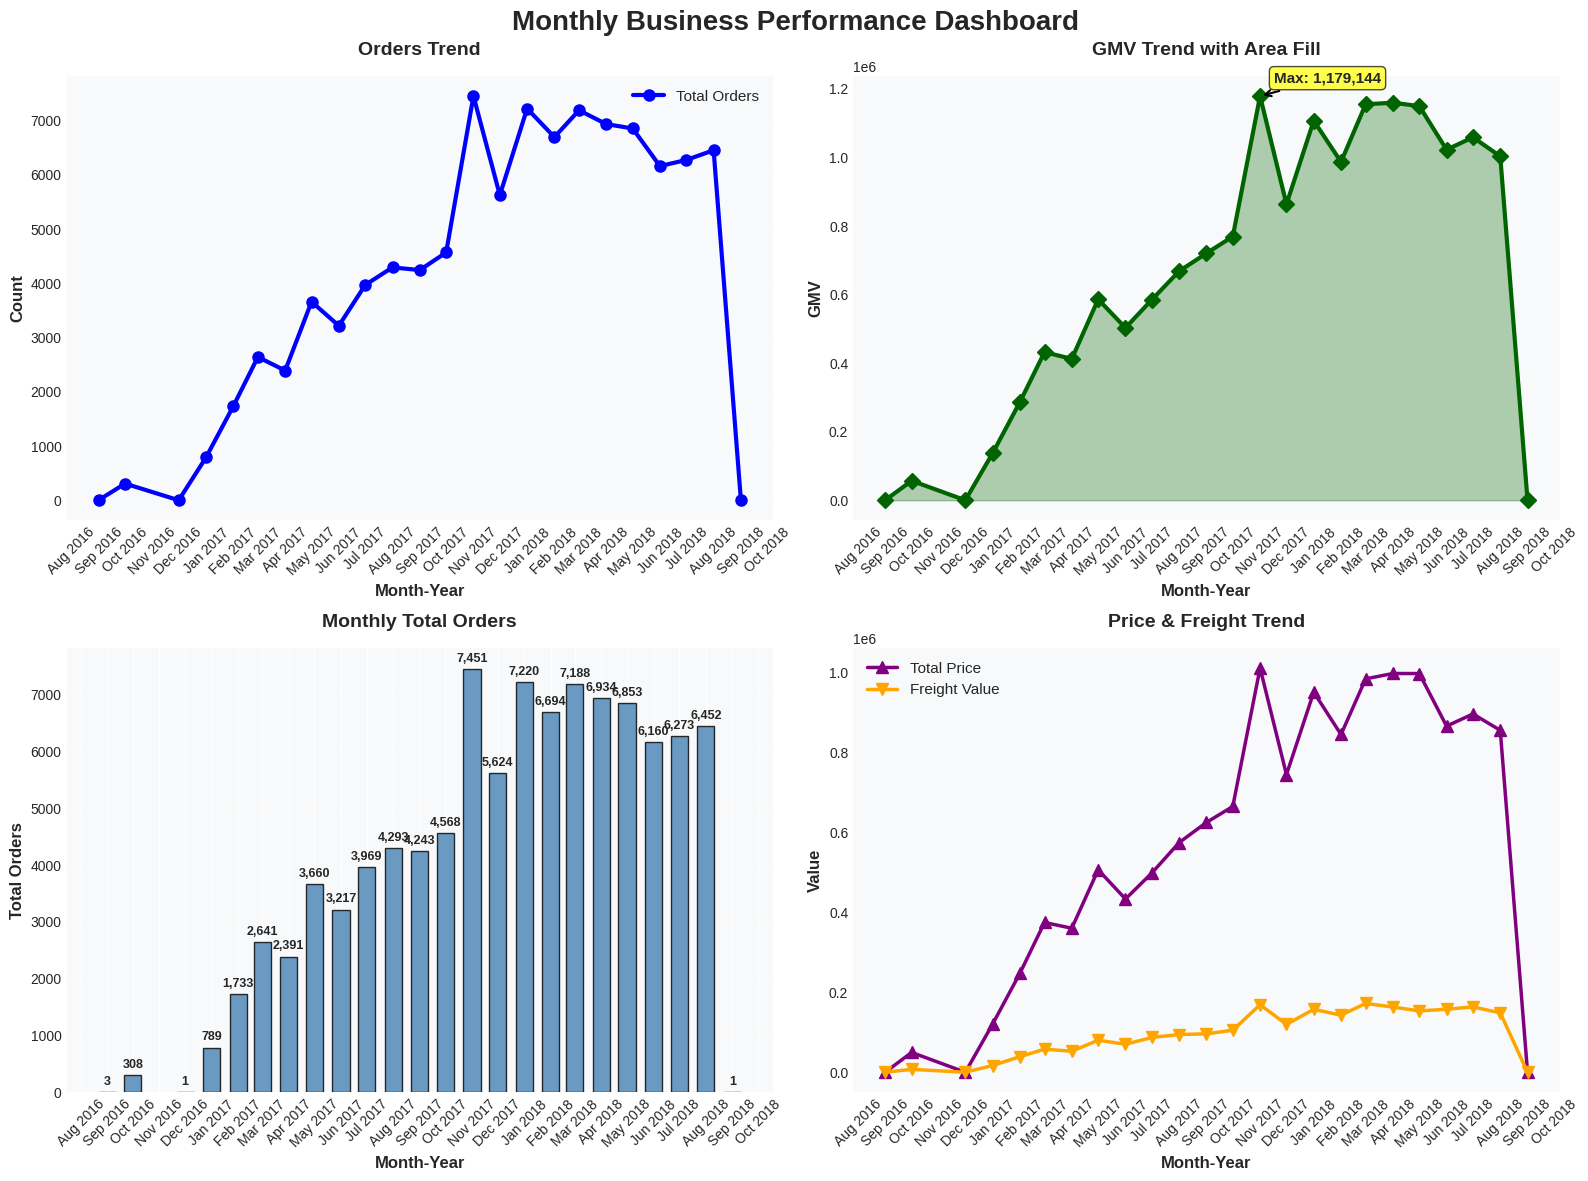

In [10]:

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Monthly Business Performance Dashboard', fontsize=20, fontweight='bold', y=0.98)

# 1. Total Orders & GMV Trend
ax1 = axes[0, 0]
ax1.plot(month_on_month_trend['month_year'], month_on_month_trend['total_orders'],
         color='blue', linewidth=3, marker='o', markersize=8, label='Total Orders')
ax1.set_xlabel('Month-Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('Orders Trend', fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=11, framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.tick_params(axis='x', rotation=45, labelsize=10)
ax1.tick_params(axis='y', labelsize=10)
ax1.set_facecolor('#f8f9fa')

# 2. GMV Only with Area Fill
ax2 = axes[0, 1]
ax2.plot(month_on_month_trend['month_year'], month_on_month_trend['GMV'],
         color='darkgreen', linewidth=3, marker='D', markersize=8)
ax2.fill_between(month_on_month_trend['month_year'], 0, month_on_month_trend['GMV'],
                 alpha=0.3, color='darkgreen')
ax2.set_xlabel('Month-Year', fontsize=12, fontweight='bold')
ax2.set_ylabel('GMV', fontsize=12, fontweight='bold')
ax2.set_title('GMV Trend with Area Fill', fontsize=14, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.tick_params(axis='x', rotation=45, labelsize=10)
ax2.tick_params(axis='y', labelsize=10)
ax2.set_facecolor('#f8f9fa')

# Annotate max value
max_gmv = month_on_month_trend['GMV'].max()
max_date = month_on_month_trend.loc[month_on_month_trend['GMV'].idxmax(), 'month_year']
ax2.annotate(f'Max: {max_gmv:,.0f}',
             xy=(max_date, max_gmv),
             xytext=(10, 10), textcoords='offset points',
             fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# 3. Total Orders with Bar Chart
ax3 = axes[1, 0]
bars = ax3.bar(month_on_month_trend['month_year'], month_on_month_trend['total_orders'],
               width=20, alpha=0.8, color='steelblue', edgecolor='black', linewidth=1)
ax3.set_xlabel('Month-Year', fontsize=12, fontweight='bold')
ax3.set_ylabel('Total Orders', fontsize=12, fontweight='bold')
ax3.set_title('Monthly Total Orders', fontsize=14, fontweight='bold', pad=15)
ax3.grid(True, alpha=0.3, linestyle='--', axis='y')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax3.xaxis.set_major_locator(mdates.MonthLocator())
ax3.tick_params(axis='x', rotation=45, labelsize=10)
ax3.tick_params(axis='y', labelsize=10)
ax3.set_facecolor('#f8f9fa')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + max(month_on_month_trend['total_orders'])*0.01,
             f'{height:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 4. Combined Metrics Comparison
ax4 = axes[1, 1]
ax4.plot(month_on_month_trend['month_year'], month_on_month_trend['total_price'],
         color='purple', linewidth=2.5, marker='^', markersize=8, label='Total Price')
ax4.plot(month_on_month_trend['month_year'], month_on_month_trend['total_freight_value'],
         color='orange', linewidth=2.5, marker='v', markersize=8, label='Freight Value')
ax4.set_xlabel('Month-Year', fontsize=12, fontweight='bold')
ax4.set_ylabel('Value', fontsize=12, fontweight='bold')
ax4.set_title('Price & Freight Trend', fontsize=14, fontweight='bold', pad=15)
ax4.legend(loc='best', fontsize=11, framealpha=0.9)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax4.xaxis.set_major_locator(mdates.MonthLocator())
ax4.tick_params(axis='x', rotation=45, labelsize=10)
ax4.tick_params(axis='y', labelsize=10)
ax4.set_facecolor('#f8f9fa')

# Adjust layout
plt.tight_layout()
plt.savefig('monthly_business_dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.savefig('monthly_business_dashboard.pdf', bbox_inches='tight', facecolor='white')
plt.show()


# Which months exhibit the strongest seasonal peaks, and what is the year-over-year growth rate?

In [11]:
# Filter out boundary artefacts (months with < 400 orders)
month_on_month_trend = month_on_month_trend[month_on_month_trend['total_orders'] >= 400].copy()

# Calculate MoM growth rates
month_on_month_trend['orders_mom_growth'] = month_on_month_trend['total_orders'].pct_change() * 100
month_on_month_trend['gmv_mom_growth']    = month_on_month_trend['GMV'].pct_change() * 100
month_on_month_trend['price_mom_growth']  = month_on_month_trend['total_price'].pct_change() * 100
month_on_month_trend['freight_mom_growth']= month_on_month_trend['total_freight_value'].pct_change() * 100

# First row will be NaN (no prior month) — expected
month_on_month_trend

,month_year,total_orders,total_price,total_freight_value,GMV,orders_mom_growth,gmv_mom_growth,price_mom_growth,freight_mom_growth
3,2017-01-01,789,120312.87,16875.62,137188.49,NaN,NaN,NaN,NaN
4,2017-02-01,1733,247303.02,38977.60,286280.62,119.645120,108.676850,105.549930,130.969884
5,2017-03-01,2641,374344.30,57704.29,432048.59,52.394691,50.917862,51.370695,48.044749
6,2017-04-01,2391,359927.23,52495.01,412422.24,-9.466111,-4.542626,-3.851286,-9.027544
7,2017-05-01,3660,506071.14,80119.81,586190.95,53.074028,42.133690,40.603738,52.623668
8,2017-06-01,3217,433038.60,69924.44,502963.04,-12.103825,-14.198089,-14.431279,-12.725155
9,2017-07-01,3969,498031.48,86940.14,584971.62,23.375816,16.305091,15.008565,24.334410
10,2017-08-01,4293,573971.68,94232.92,668204.60,8.163265,14.228550,15.248072,8.388277
11,2017-09-01,4243,624401.69,95997.22,720398.91,-1.164687,7.811127,8.786150,1.872276
12,2017-10-01,4568,664219.43,105092.94,769312.37,7.659675,6.789774,6.376943,9.474983


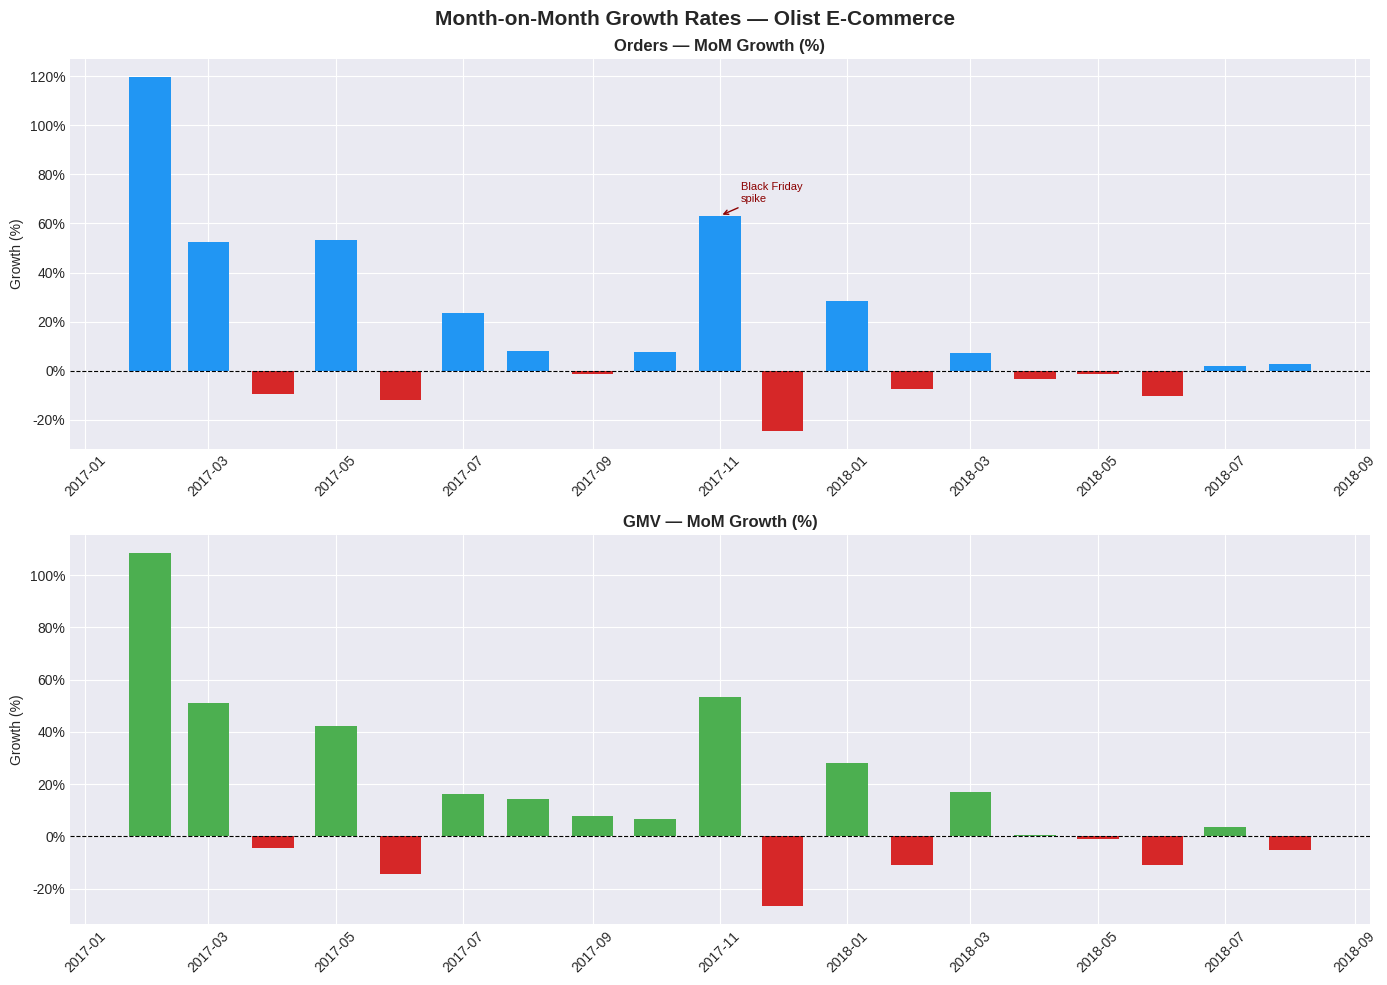

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Month-on-Month Growth Rates — Olist E-Commerce', fontsize=15, fontweight='bold')

x = month_on_month_trend['month_year']

# --- Orders MoM ---
ax1 = axes[0]
bars = ax1.bar(x, month_on_month_trend['orders_mom_growth'], color=[
    '#d62728' if v < 0 else '#2196F3' for v in month_on_month_trend['orders_mom_growth']
], width=20)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_title('Orders — MoM Growth (%)', fontweight='bold')
ax1.set_ylabel('Growth (%)')
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax1.tick_params(axis='x', rotation=45)

# Annotate Nov 2017 spike
nov_2017 = month_on_month_trend[month_on_month_trend['month_year'].dt.to_period('M') == '2017-11']
if not nov_2017.empty:
    ax1.annotate('Black Friday\nspike',
        xy=(nov_2017['month_year'].values[0], nov_2017['orders_mom_growth'].values[0]),
        xytext=(15, 10), textcoords='offset points',
        fontsize=8, color='darkred',
        arrowprops=dict(arrowstyle='->', color='darkred'))

# --- GMV MoM ---
ax2 = axes[1]
ax2.bar(x, month_on_month_trend['gmv_mom_growth'], color=[
    '#d62728' if v < 0 else '#4CAF50' for v in month_on_month_trend['gmv_mom_growth']
], width=20)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('GMV — MoM Growth (%)', fontweight='bold')
ax2.set_ylabel('Growth (%)')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('mom_growth_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# YoY — same-period comparison (Jan–Aug only, full coverage in both 2017 and 2018)
month_on_month_trend['year']  = month_on_month_trend['month_year'].dt.year
month_on_month_trend['month'] = month_on_month_trend['month_year'].dt.month

yoy = month_on_month_trend[month_on_month_trend['month'].between(1, 8)].copy()

yoy_2017 = yoy[yoy['year'] == 2017].set_index('month')
yoy_2018 = yoy[yoy['year'] == 2018].set_index('month')

yoy_comparison = pd.DataFrame({
    'orders_2017':       yoy_2017['total_orders'],
    'orders_2018':       yoy_2018['total_orders'],
    'gmv_2017':          yoy_2017['GMV'],
    'gmv_2018':          yoy_2018['GMV'],
})

yoy_comparison['orders_yoy_growth'] = (
    (yoy_comparison['orders_2018'] - yoy_comparison['orders_2017']) / yoy_comparison['orders_2017']
) * 100

yoy_comparison['gmv_yoy_growth'] = (
    (yoy_comparison['gmv_2018'] - yoy_comparison['gmv_2017']) / yoy_comparison['gmv_2017']
) * 100

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug']
yoy_comparison.index = month_labels

yoy_comparison

,orders_2017,orders_2018,gmv_2017,gmv_2018,orders_yoy_growth,gmv_yoy_growth
Jan,789,7220,137188.49,1107301.89,815.082383,707.139061
Feb,1733,6694,286280.62,986908.96,286.266590,244.734813
Mar,2641,7188,432048.59,1155126.82,172.169633,167.360396
Apr,2391,6934,412422.24,1159698.04,190.004182,181.191926
May,3660,6853,586190.95,1149781.82,87.240437,96.144587
Jun,3217,6160,502963.04,1022677.11,91.482748,103.330469
Jul,3969,6273,584971.62,1058728.03,58.049887,80.987931
Aug,4293,6452,668204.60,1003308.47,50.291172,50.149890


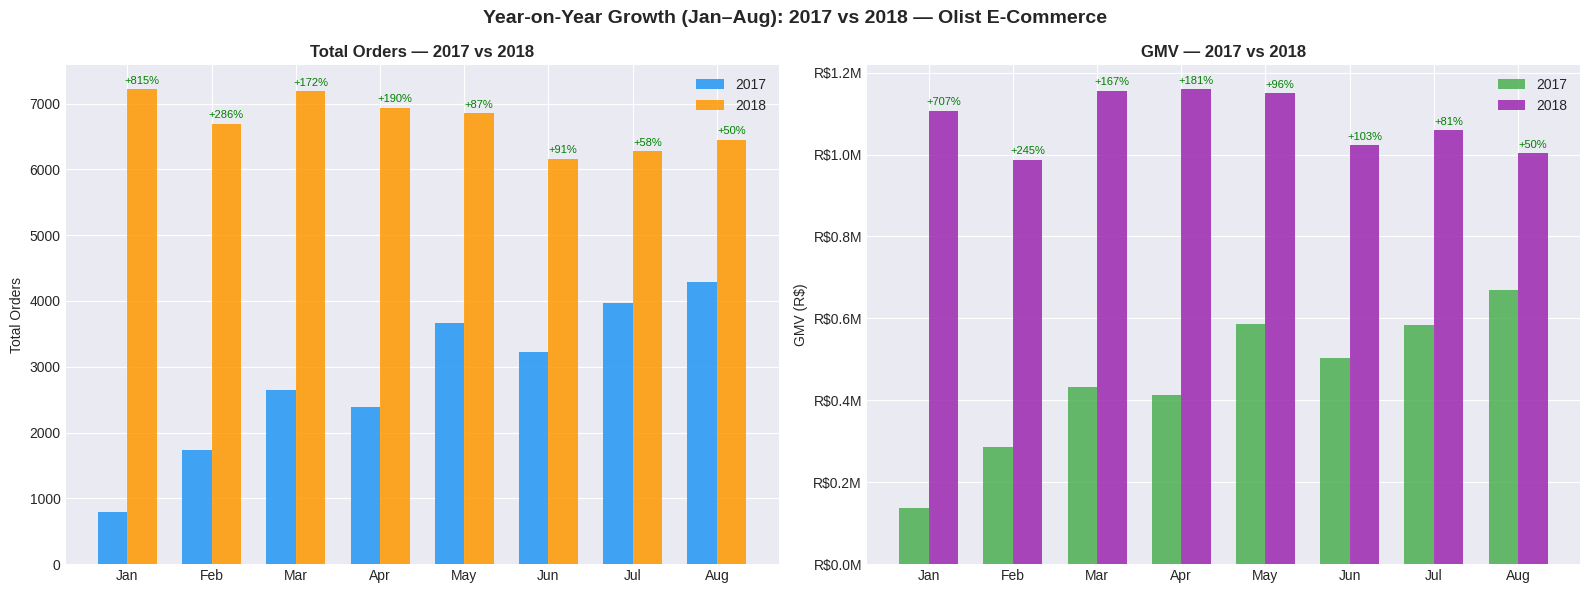

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Year-on-Year Growth (Jan–Aug): 2017 vs 2018 — Olist E-Commerce',
             fontsize=14, fontweight='bold')

x = range(len(month_labels))
width = 0.35

# --- Orders YoY grouped bar ---
ax1 = axes[0]
ax1.bar([i - width/2 for i in x], yoy_comparison['orders_2017'],
        width=width, label='2017', color='#2196F3', alpha=0.85)
ax1.bar([i + width/2 for i in x], yoy_comparison['orders_2018'],
        width=width, label='2018', color='#FF9800', alpha=0.85)
ax1.set_title('Total Orders — 2017 vs 2018', fontweight='bold')
ax1.set_ylabel('Total Orders')
ax1.set_xticks(list(x))
ax1.set_xticklabels(month_labels)
ax1.legend()

# Annotate YoY growth % above each 2018 bar
for i, (_, row) in enumerate(yoy_comparison.iterrows()):
    ax1.annotate(f"{row['orders_yoy_growth']:+.0f}%",
        xy=(i + width/2, row['orders_2018']),
        xytext=(0, 4), textcoords='offset points',
        ha='center', fontsize=8,
        color='green' if row['orders_yoy_growth'] > 0 else 'red')

# --- GMV YoY grouped bar ---
ax2 = axes[1]
ax2.bar([i - width/2 for i in x], yoy_comparison['gmv_2017'],
        width=width, label='2017', color='#4CAF50', alpha=0.85)
ax2.bar([i + width/2 for i in x], yoy_comparison['gmv_2018'],
        width=width, label='2018', color='#9C27B0', alpha=0.85)
ax2.set_title('GMV — 2017 vs 2018', fontweight='bold')
ax2.set_ylabel('GMV (R$)')
ax2.set_xticks(list(x))
ax2.set_xticklabels(month_labels)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R${v/1e6:.1f}M'))
ax2.legend()

for i, (_, row) in enumerate(yoy_comparison.iterrows()):
    ax2.annotate(f"{row['gmv_yoy_growth']:+.0f}%",
        xy=(i + width/2, row['gmv_2018']),
        xytext=(0, 4), textcoords='offset points',
        ha='center', fontsize=8,
        color='green' if row['gmv_yoy_growth'] > 0 else 'red')

plt.tight_layout()
plt.savefig('yoy_growth_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

#What proportion of orders are single-item versus multi-item, and how does basket size correlate with total order value?

In [15]:
orders_grouped_by_items=order_items.groupby('order_id').agg({'order_item_id':'count','price':'sum','freight_value':'sum'}).rename(columns={'order_item_id':'item_count'}).reset_index()

In [16]:
orders_grouped_by_items.head()

,order_id,item_count,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14


In [17]:
orders_grouped_by_items['GMV']=orders_grouped_by_items['price']+orders_grouped_by_items['freight_value']

In [18]:
orders_grouped_by_items['multi_item_order']=np.where(orders_grouped_by_items['item_count']>1,1,0)

In [19]:
orders_grouped_by_items.head()

,order_id,item_count,price,freight_value,GMV,multi_item_order
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,72.19,0
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,259.83,0
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,216.87,0
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,25.78,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,218.04,0


In [20]:
orders_category=orders_grouped_by_items.multi_item_order.value_counts(normalize=True).reset_index()
orders_category

,multi_item_order,proportion
0,0,0.900645
1,1,0.099355


/tmp/ipykernel_874/2063808567.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=orders_category_plot,


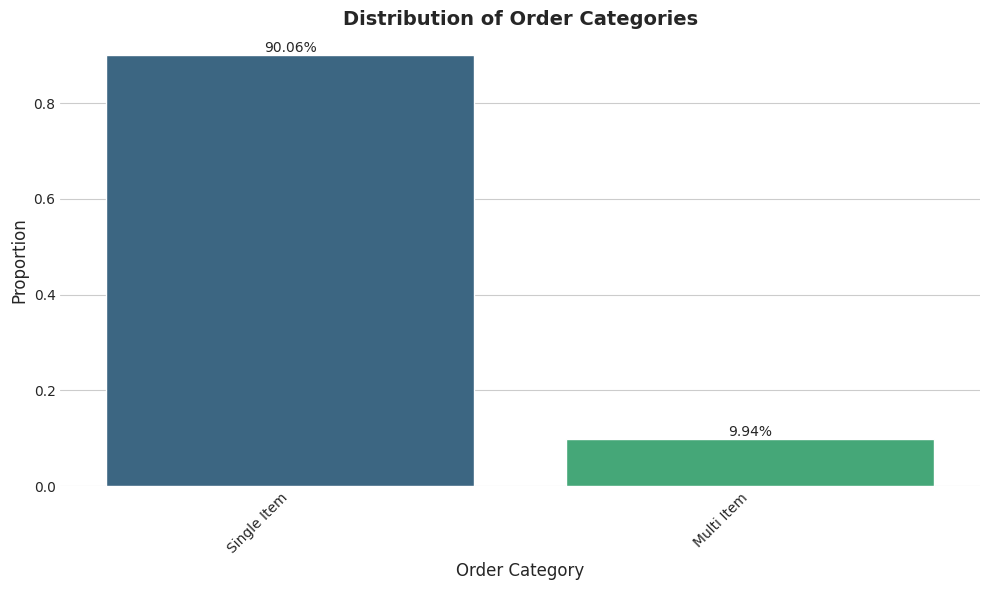

In [21]:
# Create a copy with renamed labels for plotting
orders_category_plot = orders_category.copy()
orders_category_plot['multi_item_order'] = orders_category_plot['multi_item_order'].map({0: 'Single Item', 1: 'Multi Item'})

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Create bar plot with renamed labels
ax = sns.barplot(data=orders_category_plot,
                 x='multi_item_order',
                 y='proportion',
                 palette='viridis')

# Add labels and title
plt.xlabel('Order Category', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.title('Distribution of Order Categories', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Add value labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=10)

plt.tight_layout()
plt.savefig('order_category_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# Point-biserial correlation
correlation, p_value = stats.pointbiserialr(orders_grouped_by_items['multi_item_order'], orders_grouped_by_items['GMV'])

print(f"Point-Biserial Correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("Statistically significant correlation")
    if correlation > 0:
        print("Multi-item orders tend to have higher GMV")
    else:
        print("Multi-item orders tend to have lower GMV")
else:
    print("No statistically significant correlation")

Point-Biserial Correlation: 0.1343
P-value: 0.0000
Statistically significant correlation
Multi-item orders tend to have higher GMV


# What is the distribution of freight value relative to product price, and how does this vary by customer state?

In [23]:
try:
   customers=pd.read_parquet('customers.parquet')
except Exception as e:
   print("something went wrong: " + e.message)

In [24]:
orders_customers=orders.merge(customers,on='customer_id')

In [25]:
orders_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,03149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,09195,santo andre,SP


In [26]:
orders_customers_order_items=orders_customers.merge(order_items,on='order_id')

In [27]:
orders_customers_order_items.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,03149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,09195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [28]:
orders_customers_order_items['freight_value_per_price']=orders_customers_order_items['freight_value']/orders_customers_order_items['price']


In [29]:
orders_customers_order_items

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,freight_value_per_price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,03149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,0.290764
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,0.191744
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,0.120200
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,0.604444
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,09195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,0.438191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10,0.114923
112646,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,1,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02,0.315646
112647,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,0.225513
112648,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,2,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,0.225513


=== FREIGHT-TO-PRICE RATIO DISTRIBUTION ===

Basic Statistics:
count    112650.000000
mean          0.320864
std           0.349894
min           0.000000
25%           0.134034
50%           0.231356
75%           0.393036
max          26.235294
Name: freight_value_per_price, dtype: float64

Percentiles:
    1.0th percentile: 0.0234
    5.0th percentile: 0.0535
   10.0th percentile: 0.0787
   25.0th percentile: 0.1340
   50.0th percentile: 0.2314
   75.0th percentile: 0.3930
   90.0th percentile: 0.6429
   95.0th percentile: 0.8747
   99.0th percentile: 1.5495

Key Metrics:
  Mean: 0.3209
  Median: 0.2314
  Std Dev: 0.3499
  Skewness: 11.7865

Freight as % of Price - Distribution:
Freight Category  Proportion
             <5%    0.040083
           5-10%    0.112473
          10-15%    0.139899
          15-20%    0.139257
          20-30%    0.201439
          30-50%    0.198135
         50-100%    0.131980
           >100%    0.036734


/tmp/ipykernel_874/993953100.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='price_category', y='freight_value_per_price',
/tmp/ipykernel_874/993953100.py:148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='price_category', y='freight_value_per_price',


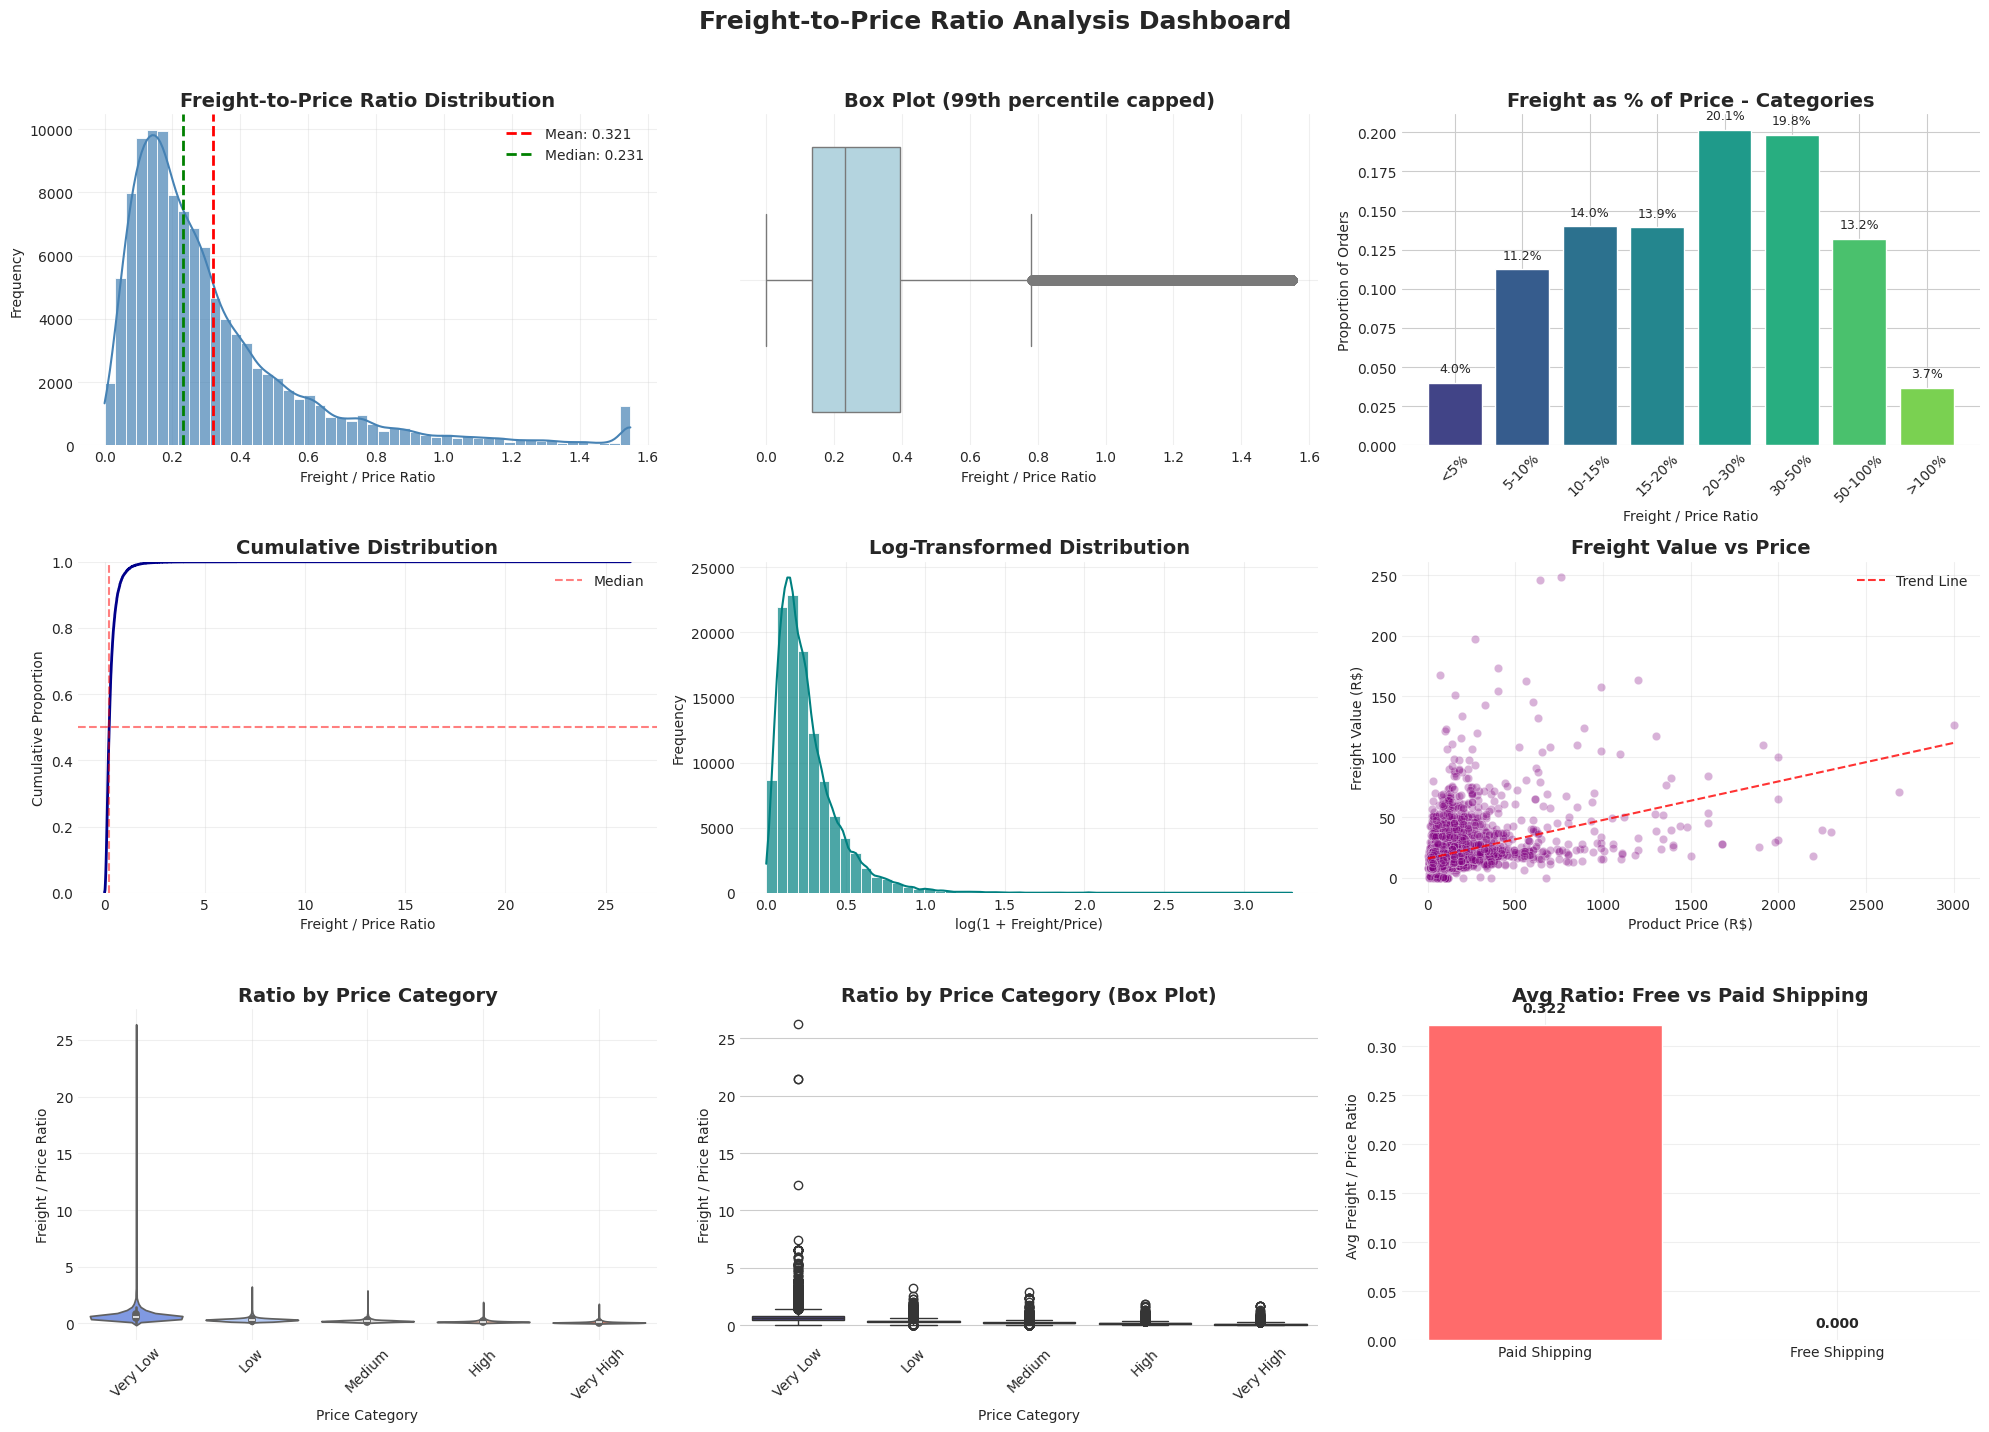

In [55]:
df = orders_customers_order_items.copy()

# ============ 1. SUMMARY STATISTICS ============

print("=== FREIGHT-TO-PRICE RATIO DISTRIBUTION ===")
print("=" * 50)

# Basic stats
print("\nBasic Statistics:")
print(df['freight_value_per_price'].describe())

# Percentiles for deeper understanding
percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
print("\nPercentiles:")
for p in percentiles:
    val = df['freight_value_per_price'].quantile(p)
    print(f"  {p*100:5.1f}th percentile: {val:.4f}")

# Key metrics
print("\nKey Metrics:")
print(f"  Mean: {df['freight_value_per_price'].mean():.4f}")
print(f"  Median: {df['freight_value_per_price'].median():.4f}")
print(f"  Std Dev: {df['freight_value_per_price'].std():.4f}")
print(f"  Skewness: {df['freight_value_per_price'].skew():.4f}")

# Categorical breakdown
df['freight_category'] = pd.cut(df['freight_value_per_price'],
                                 bins=[0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 1.0, float('inf')],
                                 labels=['<5%', '5-10%', '10-15%', '15-20%', '20-30%', '30-50%', '50-100%', '>100%'])

category_dist = df['freight_category'].value_counts(normalize=True).reset_index()
category_dist.columns = ['Freight Category', 'Proportion']
category_dist = category_dist.sort_values('Freight Category')

print("\nFreight as % of Price - Distribution:")
print(category_dist.to_string(index=False))

# ============ 2. VISUALIZATIONS ============

# Create a comprehensive dashboard
fig = plt.figure(figsize=(20, 14))

# 2.1 Main Distribution - Histogram with KDE
ax1 = plt.subplot(3, 3, 1)
# Cap at 99th percentile for better visualization
capped_data = df['freight_value_per_price'].clip(upper=df['freight_value_per_price'].quantile(0.99))
sns.histplot(capped_data, bins=50, kde=True, color='steelblue', alpha=0.7)
ax1.axvline(df['freight_value_per_price'].mean(), color='red', linestyle='--',
            linewidth=2, label=f'Mean: {df["freight_value_per_price"].mean():.3f}')
ax1.axvline(df['freight_value_per_price'].median(), color='green', linestyle='--',
            linewidth=2, label=f'Median: {df["freight_value_per_price"].median():.3f}')
ax1.set_title('Freight-to-Price Ratio Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Freight / Price Ratio')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2.2 Box Plot
ax2 = plt.subplot(3, 3, 2)
# Cap outliers for better visualization
sns.boxplot(x=capped_data, color='lightblue', ax=ax2)
ax2.set_title('Box Plot (99th percentile capped)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Freight / Price Ratio')
ax2.grid(True, alpha=0.3)

# 2.3 Categorical Distribution
ax3 = plt.subplot(3, 3, 3)
bars = ax3.bar(category_dist['Freight Category'], category_dist['Proportion'],
               color=plt.cm.viridis(np.linspace(0.2, 0.8, len(category_dist))))
ax3.set_title('Freight as % of Price - Categories', fontsize=14, fontweight='bold')
ax3.set_xlabel('Freight / Price Ratio')
ax3.set_ylabel('Proportion of Orders')
ax3.tick_params(axis='x', rotation=45)

# Add percentage labels
for bar, p in zip(bars, category_dist['Proportion']):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{p:.1%}', ha='center', va='bottom', fontsize=9)

# 2.4 Cumulative Distribution (ECDF)
ax4 = plt.subplot(3, 3, 4)
sns.ecdfplot(df['freight_value_per_price'], ax=ax4, color='darkblue', linewidth=2)
ax4.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Median')
ax4.axvline(x=df['freight_value_per_price'].median(), color='red', linestyle='--', alpha=0.5)
ax4.set_title('Cumulative Distribution', fontsize=14, fontweight='bold')
ax4.set_xlabel('Freight / Price Ratio')
ax4.set_ylabel('Cumulative Proportion')
ax4.grid(True, alpha=0.3)
ax4.legend()

# 2.5 Log-transformed Distribution
ax5 = plt.subplot(3, 3, 5)
df['log_ratio'] = np.log1p(df['freight_value_per_price'])
sns.histplot(df['log_ratio'], bins=50, kde=True, color='teal', alpha=0.7)
ax5.set_title('Log-Transformed Distribution', fontsize=14, fontweight='bold')
ax5.set_xlabel('log(1 + Freight/Price)')
ax5.set_ylabel('Frequency')
ax5.grid(True, alpha=0.3)

# 2.6 Scatter Plot: Price vs Freight
ax6 = plt.subplot(3, 3, 6)
sample = df.sample(min(5000, len(df)))
sns.scatterplot(data=sample, x='price', y='freight_value',
                alpha=0.3, color='purple', ax=ax6)
ax6.set_title('Freight Value vs Price', fontsize=14, fontweight='bold')
ax6.set_xlabel('Product Price (R$)')
ax6.set_ylabel('Freight Value (R$)')
ax6.grid(True, alpha=0.3)

# Add a trend line
z = np.polyfit(sample['price'], sample['freight_value'], 1)
p = np.poly1d(z)
ax6.plot(sample['price'].sort_values(), p(sample['price'].sort_values()),
         "r--", alpha=0.8, label='Trend Line')
ax6.legend()

# 2.7 Violin Plot by Price Category
ax7 = plt.subplot(3, 3, 7)
df['price_category'] = pd.qcut(df['price'], q=5,
                                labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
sns.violinplot(data=df, x='price_category', y='freight_value_per_price',
               palette='coolwarm', ax=ax7)
ax7.set_title('Ratio by Price Category', fontsize=14, fontweight='bold')
ax7.set_xlabel('Price Category')
ax7.set_ylabel('Freight / Price Ratio')
ax7.tick_params(axis='x', rotation=45)
ax7.grid(True, alpha=0.3)

# 2.8 Box Plot by Product Category (Top 10)
ax8 = plt.subplot(3, 3, 8)
# If you have product category names
if 'product_category_name' in df.columns:
    top_categories = df['product_category_name'].value_counts().head(10).index
    top_cat_data = df[df['product_category_name'].isin(top_categories)]
    # Cap extreme values for visualization
    top_cat_data['ratio_capped'] = top_cat_data['freight_value_per_price'].clip(
        upper=top_cat_data['freight_value_per_price'].quantile(0.95)
    )
    sns.boxplot(data=top_cat_data, x='product_category_name', y='ratio_capped',
                palette='viridis', ax=ax8)
    ax8.set_title('Ratio by Top 10 Product Categories', fontsize=14, fontweight='bold')
    ax8.set_xlabel('Product Category')
    ax8.set_ylabel('Freight / Price Ratio')
    ax8.tick_params(axis='x', rotation=45)
else:
    # Alternative: by price bracket
    sns.boxplot(data=df, x='price_category', y='freight_value_per_price',
                palette='viridis', ax=ax8)
    ax8.set_title('Ratio by Price Category (Box Plot)', fontsize=14, fontweight='bold')
    ax8.set_xlabel('Price Category')
    ax8.set_ylabel('Freight / Price Ratio')
    ax8.tick_params(axis='x', rotation=45)

# 2.9 Free Shipping Analysis
ax9 = plt.subplot(3, 3, 9)
free_shipping = df['freight_value'] == 0
free_stats = df.groupby(free_shipping)['freight_value_per_price'].mean()
labels = ['Paid Shipping', 'Free Shipping']
values = [free_stats[False] if False in free_stats.index else 0,
          free_stats[True] if True in free_stats.index else 0]
ax9.bar(labels, values, color=['#FF6B6B', '#4ECDC4'])
ax9.set_title('Avg Ratio: Free vs Paid Shipping', fontsize=14, fontweight='bold')
ax9.set_ylabel('Avg Freight / Price Ratio')
ax9.grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate(values):
    ax9.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Freight-to-Price Ratio Analysis Dashboard', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('freight_price_ratio_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

=== FREIGHT-TO-PRICE RATIO BY CUSTOMER STATE ===

State-Level Statistics (Sorted by Mean Ratio):
                Order_Count  Mean_Ratio  Median_Ratio  Std_Ratio  Min_Ratio  \
customer_state                                                                
RO                      278      0.5942        0.3983     0.5350     0.0000   
RR                       52      0.5890        0.3957     0.4677     0.0457   
MA                      824      0.5493        0.3922     0.5184     0.0000   
AC                       92      0.5117        0.3484     0.4999     0.0349   
PB                      602      0.5116        0.3674     0.5035     0.0000   
RN                      529      0.5063        0.3200     0.5369     0.0000   
PI                      542      0.4998        0.3329     0.4874     0.0000   
TO                      315      0.4995        0.3643     0.4557     0.0000   
AM                      165      0.4981        0.4098     0.3980     0.0334   
AL                      444      0

/tmp/ipykernel_874/2043399137.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(state_data, labels=state_labels, patch_artist=True)
/tmp/ipykernel_874/2043399137.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=top10_data, x='customer_state', y='freight_value_per_price',
/tmp/ipykernel_874/2043399137.py:170: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comparison_data['state_group'] = comparison_data['customer_state'].apply(


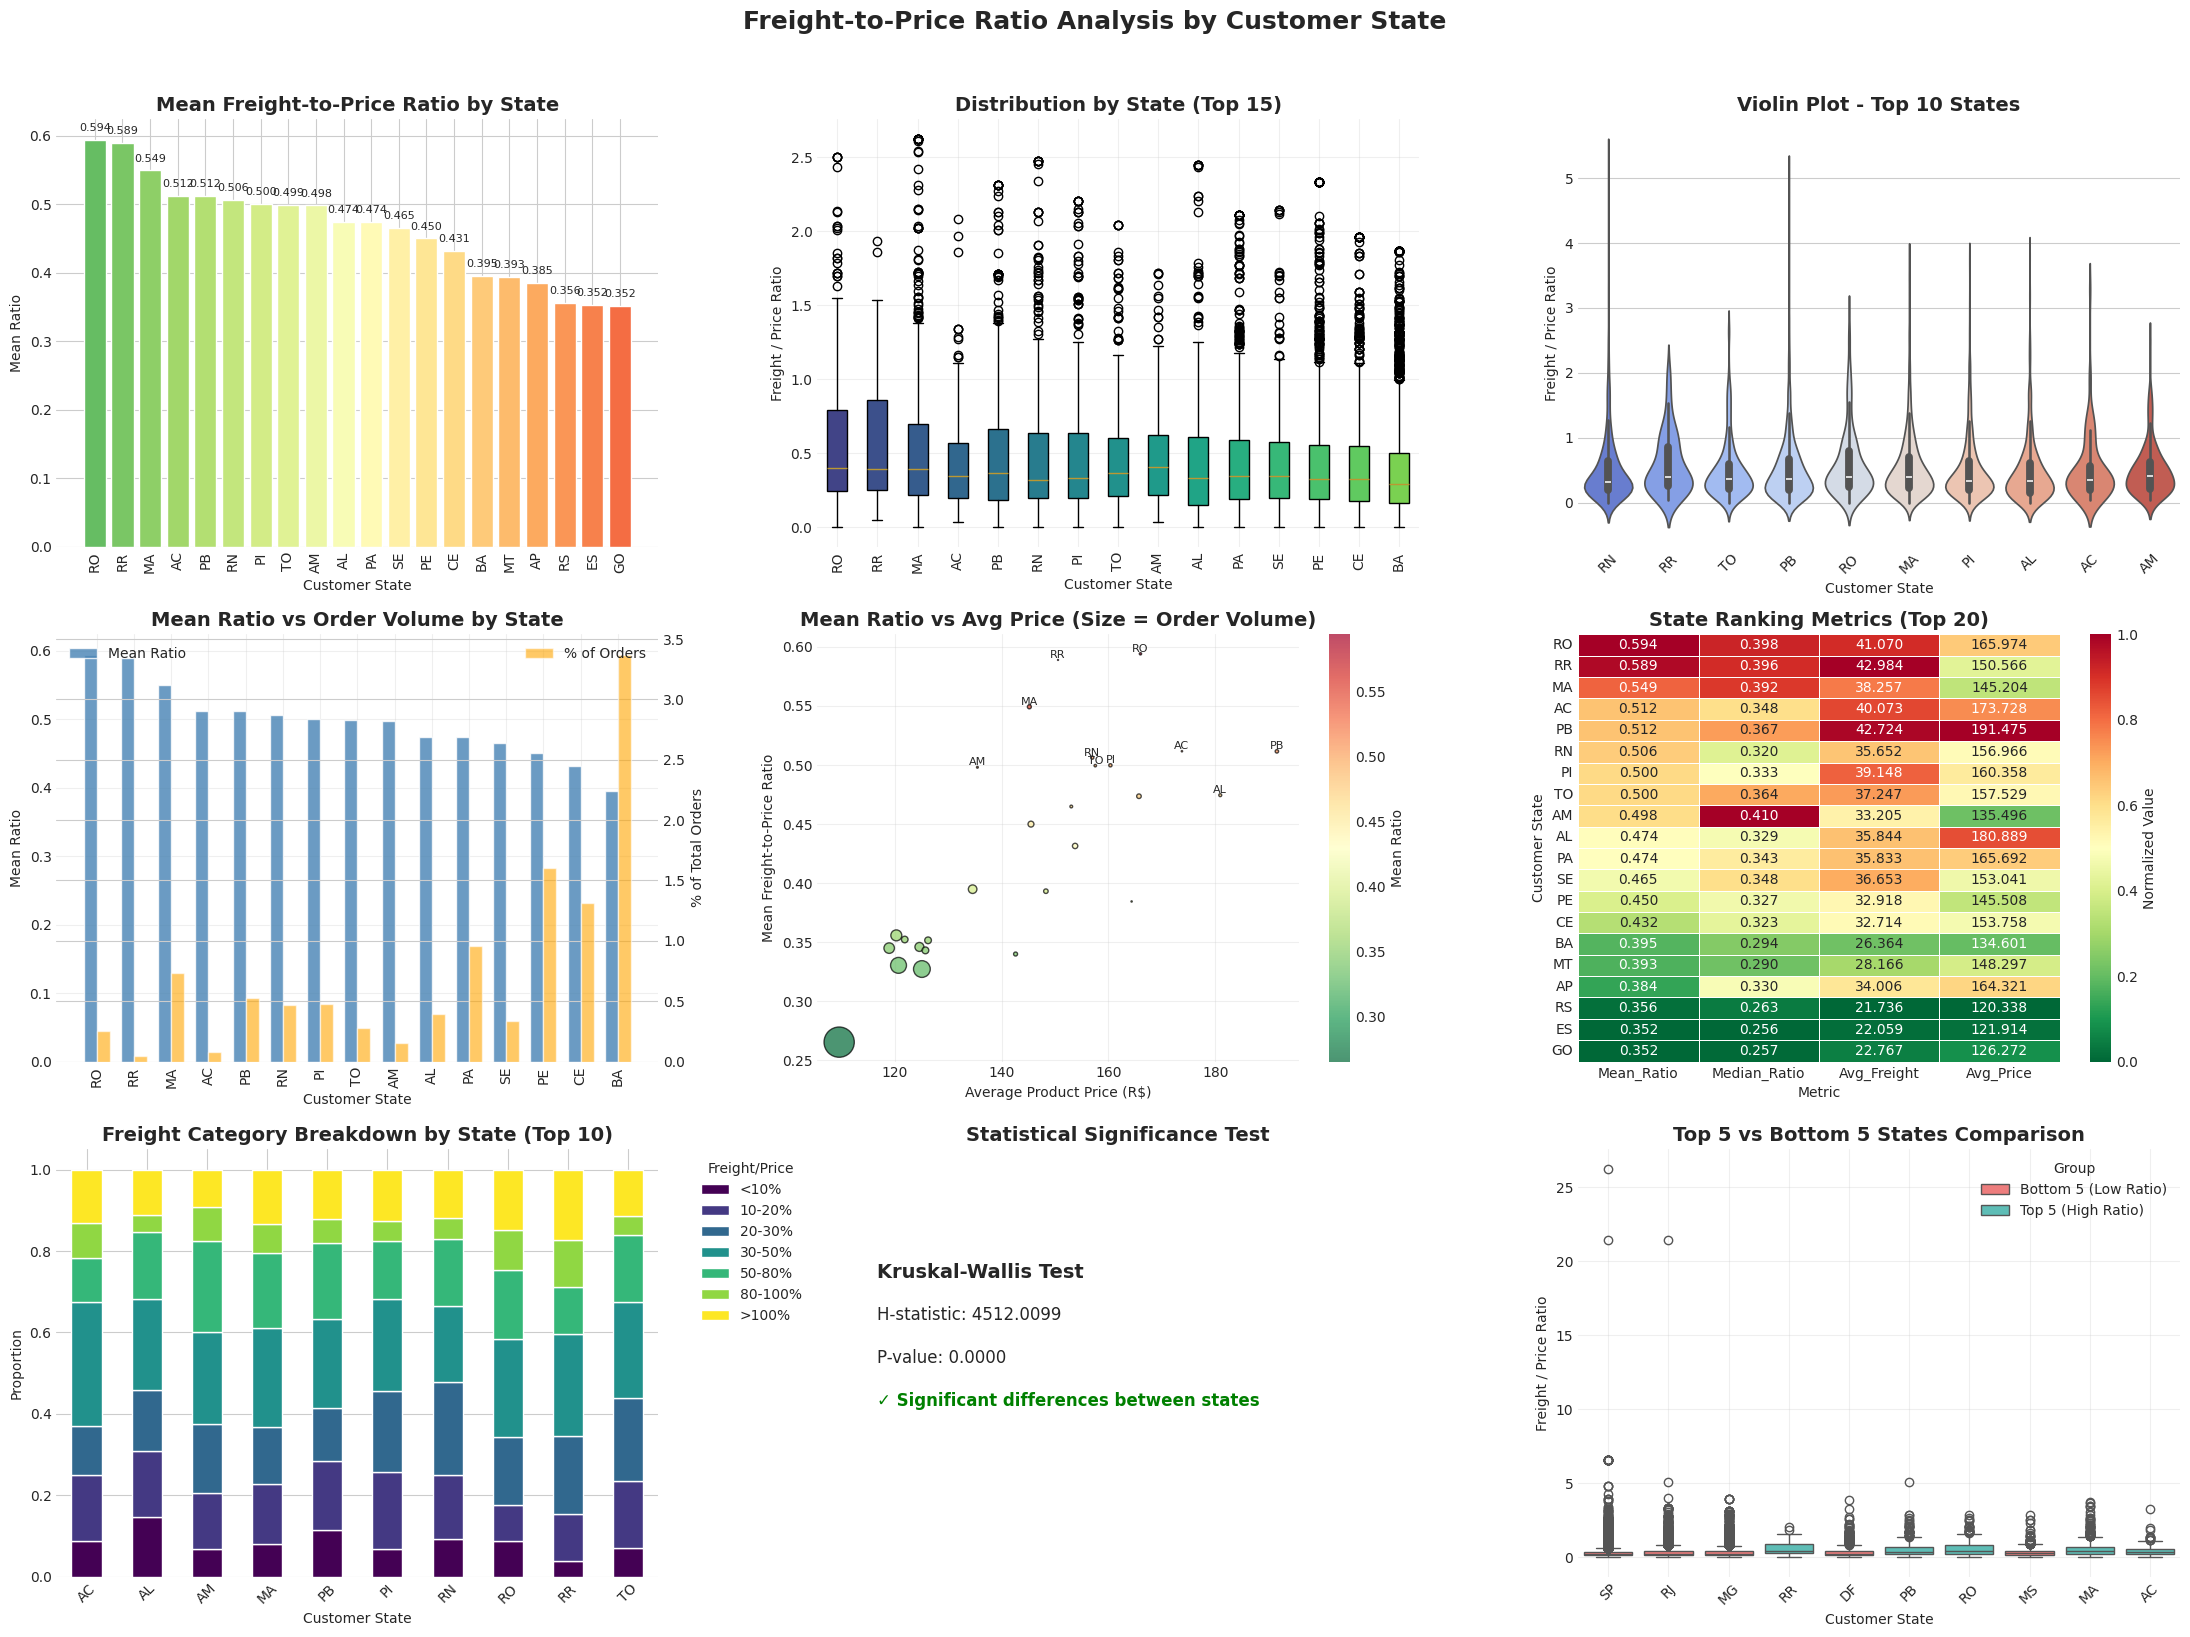

In [31]:
df = orders_customers_order_items.copy()

# ============ 1. STATE-LEVEL SUMMARY STATISTICS ============

print("=== FREIGHT-TO-PRICE RATIO BY CUSTOMER STATE ===")
print("=" * 60)

# Calculate state-level statistics
state_stats = df.groupby('customer_state').agg({
    'freight_value_per_price': ['count', 'mean', 'median', 'std', 'min', 'max'],
    'freight_value': 'mean',
    'price': 'mean'
}).round(4)

state_stats.columns = ['Order_Count', 'Mean_Ratio', 'Median_Ratio', 'Std_Ratio',
                       'Min_Ratio', 'Max_Ratio', 'Avg_Freight', 'Avg_Price']

# Sort by mean ratio descending
state_stats = state_stats.sort_values('Mean_Ratio', ascending=False)

print("\nState-Level Statistics (Sorted by Mean Ratio):")
print(state_stats)

# Add percentage of total orders
state_stats['%_of_Orders'] = (state_stats['Order_Count'] / state_stats['Order_Count'].sum() * 100).round(2)
print("\nWith Percentage of Total Orders:")
print(state_stats[['Order_Count', '%_of_Orders', 'Mean_Ratio', 'Median_Ratio']])

# ============ 2. VISUALIZATIONS ============

# Create comprehensive dashboard
fig = plt.figure(figsize=(22, 16))

# 2.1 Bar Plot - Mean Ratio by State (Top 20 states)
ax1 = plt.subplot(3, 3, 1)
top_states = state_stats.head(20)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_states)))
bars = ax1.bar(top_states.index, top_states['Mean_Ratio'], color=colors)
ax1.set_title('Mean Freight-to-Price Ratio by State', fontsize=14, fontweight='bold')
ax1.set_xlabel('Customer State')
ax1.set_ylabel('Mean Ratio')
ax1.tick_params(axis='x', rotation=90)

# Add value labels
for bar, val in zip(bars, top_states['Mean_Ratio']):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# 2.2 Box Plot - Distribution by State
ax2 = plt.subplot(3, 3, 2)
# Cap extreme values for better visualization
state_data = []
state_labels = []
for state in state_stats.head(15).index:
    state_vals = df[df['customer_state'] == state]['freight_value_per_price']
    # Cap at 99th percentile
    capped_vals = state_vals.clip(upper=state_vals.quantile(0.99))
    state_data.append(capped_vals)
    state_labels.append(state)

bp = ax2.boxplot(state_data, labels=state_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.viridis(np.linspace(0.2, 0.8, len(state_data)))):
    patch.set_facecolor(color)
ax2.set_title('Distribution by State (Top 15)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Customer State')
ax2.set_ylabel('Freight / Price Ratio')
ax2.tick_params(axis='x', rotation=90)
ax2.grid(True, alpha=0.3)

# 2.3 Violin Plot - Top 10 States
ax3 = plt.subplot(3, 3, 3)
top10_states = state_stats.head(10).index
top10_data = df[df['customer_state'].isin(top10_states)]
sns.violinplot(data=top10_data, x='customer_state', y='freight_value_per_price',
               palette='coolwarm', ax=ax3)
ax3.set_title('Violin Plot - Top 10 States', fontsize=14, fontweight='bold')
ax3.set_xlabel('Customer State')
ax3.set_ylabel('Freight / Price Ratio')
ax3.tick_params(axis='x', rotation=45)

# 2.4 Geographic Distribution (Simulated - Bar Chart)
ax4 = plt.subplot(3, 3, 4)
# Show mean ratio and order volume together
x_pos = np.arange(len(top_states.head(15)))
width = 0.35
state_subset = state_stats.head(15)
bars1 = ax4.bar(x_pos - width/2, state_subset['Mean_Ratio'], width, label='Mean Ratio', color='steelblue', alpha=0.8)
ax4_2 = ax4.twinx()
bars2 = ax4_2.bar(x_pos + width/2, state_subset['%_of_Orders'], width, label='% of Orders', color='orange', alpha=0.6)
ax4.set_xlabel('Customer State')
ax4.set_ylabel('Mean Ratio')
ax4_2.set_ylabel('% of Total Orders')
ax4.set_title('Mean Ratio vs Order Volume by State', fontsize=14, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(state_subset.index, rotation=90)
ax4.legend(loc='upper left')
ax4_2.legend(loc='upper right')
ax4.grid(True, alpha=0.3)

# 2.5 Scatter Plot: Mean Ratio vs Average Price
ax5 = plt.subplot(3, 3, 5)
scatter = ax5.scatter(state_stats['Avg_Price'], state_stats['Mean_Ratio'],
                      s=state_stats['Order_Count']/100,  # Size = order volume
                      c=state_stats['Mean_Ratio'], cmap='RdYlGn_r',
                      alpha=0.7, edgecolors='black', linewidth=1)
ax5.set_xlabel('Average Product Price (R$)')
ax5.set_ylabel('Mean Freight-to-Price Ratio')
ax5.set_title('Mean Ratio vs Avg Price (Size = Order Volume)', fontsize=14, fontweight='bold')
ax5.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax5, label='Mean Ratio')

# Add state labels for top states
for state in state_stats.head(10).index:
    ax5.annotate(state, (state_stats.loc[state, 'Avg_Price'],
                        state_stats.loc[state, 'Mean_Ratio']),
                 fontsize=8, ha='center', va='bottom')

# 2.6 Heatmap of State Ranking
ax6 = plt.subplot(3, 3, 6)
# Create ranking matrix
ranking_data = state_stats[['Mean_Ratio', 'Median_Ratio', 'Avg_Freight', 'Avg_Price']].head(20)
# Normalize for heatmap
ranking_norm = (ranking_data - ranking_data.min()) / (ranking_data.max() - ranking_data.min())
sns.heatmap(ranking_norm, annot=ranking_data.round(3), fmt='.3f', cmap='RdYlGn_r',
            cbar_kws={'label': 'Normalized Value'}, ax=ax6, linewidths=0.5)
ax6.set_title('State Ranking Metrics (Top 20)', fontsize=14, fontweight='bold')
ax6.set_xlabel('Metric')
ax6.set_ylabel('Customer State')

# 2.7 Freight Category Breakdown by State (Top 10)
ax7 = plt.subplot(3, 3, 7)
# Create freight categories for top states
df['freight_category'] = pd.cut(df['freight_value_per_price'],
                                 bins=[0, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0, float('inf')],
                                 labels=['<10%', '10-20%', '20-30%', '30-50%', '50-80%', '80-100%', '>100%'])

top10_data = df[df['customer_state'].isin(top10_states)]
# Create cross-tabulation
crosstab = pd.crosstab(top10_data['customer_state'], top10_data['freight_category'], normalize='index')
crosstab.plot(kind='bar', stacked=True, ax=ax7, colormap='viridis')
ax7.set_title('Freight Category Breakdown by State (Top 10)', fontsize=14, fontweight='bold')
ax7.set_xlabel('Customer State')
ax7.set_ylabel('Proportion')
ax7.tick_params(axis='x', rotation=45)
ax7.legend(title='Freight/Price', bbox_to_anchor=(1.05, 1), loc='upper left')

# 2.8 Statistical Significance - ANOVA
ax8 = plt.subplot(3, 3, 8)
# Perform ANOVA to test if states differ significantly
state_groups = [group['freight_value_per_price'].values for name, group in df.groupby('customer_state')]
# Use Kruskal-Wallis (non-parametric ANOVA)
h_stat, p_val = stats.kruskal(*state_groups)
# Show results
ax8.text(0.1, 0.7, f'Kruskal-Wallis Test', fontsize=14, fontweight='bold')
ax8.text(0.1, 0.6, f'H-statistic: {h_stat:.4f}', fontsize=12)
ax8.text(0.1, 0.5, f'P-value: {p_val:.4f}', fontsize=12)
if p_val < 0.05:
    ax8.text(0.1, 0.4, '✓ Significant differences between states', color='green', fontsize=12, fontweight='bold')
else:
    ax8.text(0.1, 0.4, '✗ No significant differences between states', color='red', fontsize=12, fontweight='bold')
ax8.set_title('Statistical Significance Test', fontsize=14, fontweight='bold')
ax8.axis('off')

# 2.9 Top vs Bottom States Comparison
ax9 = plt.subplot(3, 3, 9)
top5 = state_stats.head(5).index.tolist()
bottom5 = state_stats.tail(5).index.tolist()
comparison_states = top5 + bottom5
comparison_data = df[df['customer_state'].isin(comparison_states)]
comparison_data['state_group'] = comparison_data['customer_state'].apply(
    lambda x: 'Top 5 (High Ratio)' if x in top5 else 'Bottom 5 (Low Ratio)'
)
sns.boxplot(data=comparison_data, x='customer_state', y='freight_value_per_price',
            hue='state_group', palette=['#FF6B6B', '#4ECDC4'], ax=ax9)
ax9.set_title('Top 5 vs Bottom 5 States Comparison', fontsize=14, fontweight='bold')
ax9.set_xlabel('Customer State')
ax9.set_ylabel('Freight / Price Ratio')
ax9.tick_params(axis='x', rotation=45)
ax9.legend(title='Group')
ax9.grid(True, alpha=0.3)

plt.suptitle('Freight-to-Price Ratio Analysis by Customer State', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('freight_price_ratio_by_state_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

# What is the average order processing time (purchase to approval) and how has it trended over the dataset period?

In [32]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [33]:
orders['order_processing_time_hours'] = (
    orders['order_approved_at'] - orders['order_purchase_timestamp']
).dt.total_seconds() / 3600

# Mean processing time in hours
mean_hours = orders['order_processing_time_hours'].mean()
print(f"Mean Order Processing Time: {mean_hours:.2f} hours")
print(f"Mean Order Processing Time: {mean_hours/24:.2f} days")
print(f"Mean Order Processing Time: {mean_hours*60:.2f} minutes")

Mean Order Processing Time: 10.42 hours
Mean Order Processing Time: 0.43 days
Mean Order Processing Time: 625.15 minutes



=== ORDER PROCESSING TIME DISTRIBUTION (HOURS) ===

Summary Statistics:
count    99281.000000
mean        10.419094
std         26.038004
min          0.000000
25%          0.215000
50%          0.343333
75%         14.580833
max       4509.180556
Name: order_processing_time_hours, dtype: float64

Percentiles:
    5.0th percentile: 0.14 hours (0.01 days)
   10.0th percentile: 0.17 hours (0.01 days)
   25.0th percentile: 0.21 hours (0.01 days)
   50.0th percentile: 0.34 hours (0.01 days)
   75.0th percentile: 14.58 hours (0.61 days)
   90.0th percentile: 34.66 hours (1.44 days)
   95.0th percentile: 48.46 hours (2.02 days)
   99.0th percentile: 90.17 hours (3.76 days)


/tmp/ipykernel_874/2928297195.py:93: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


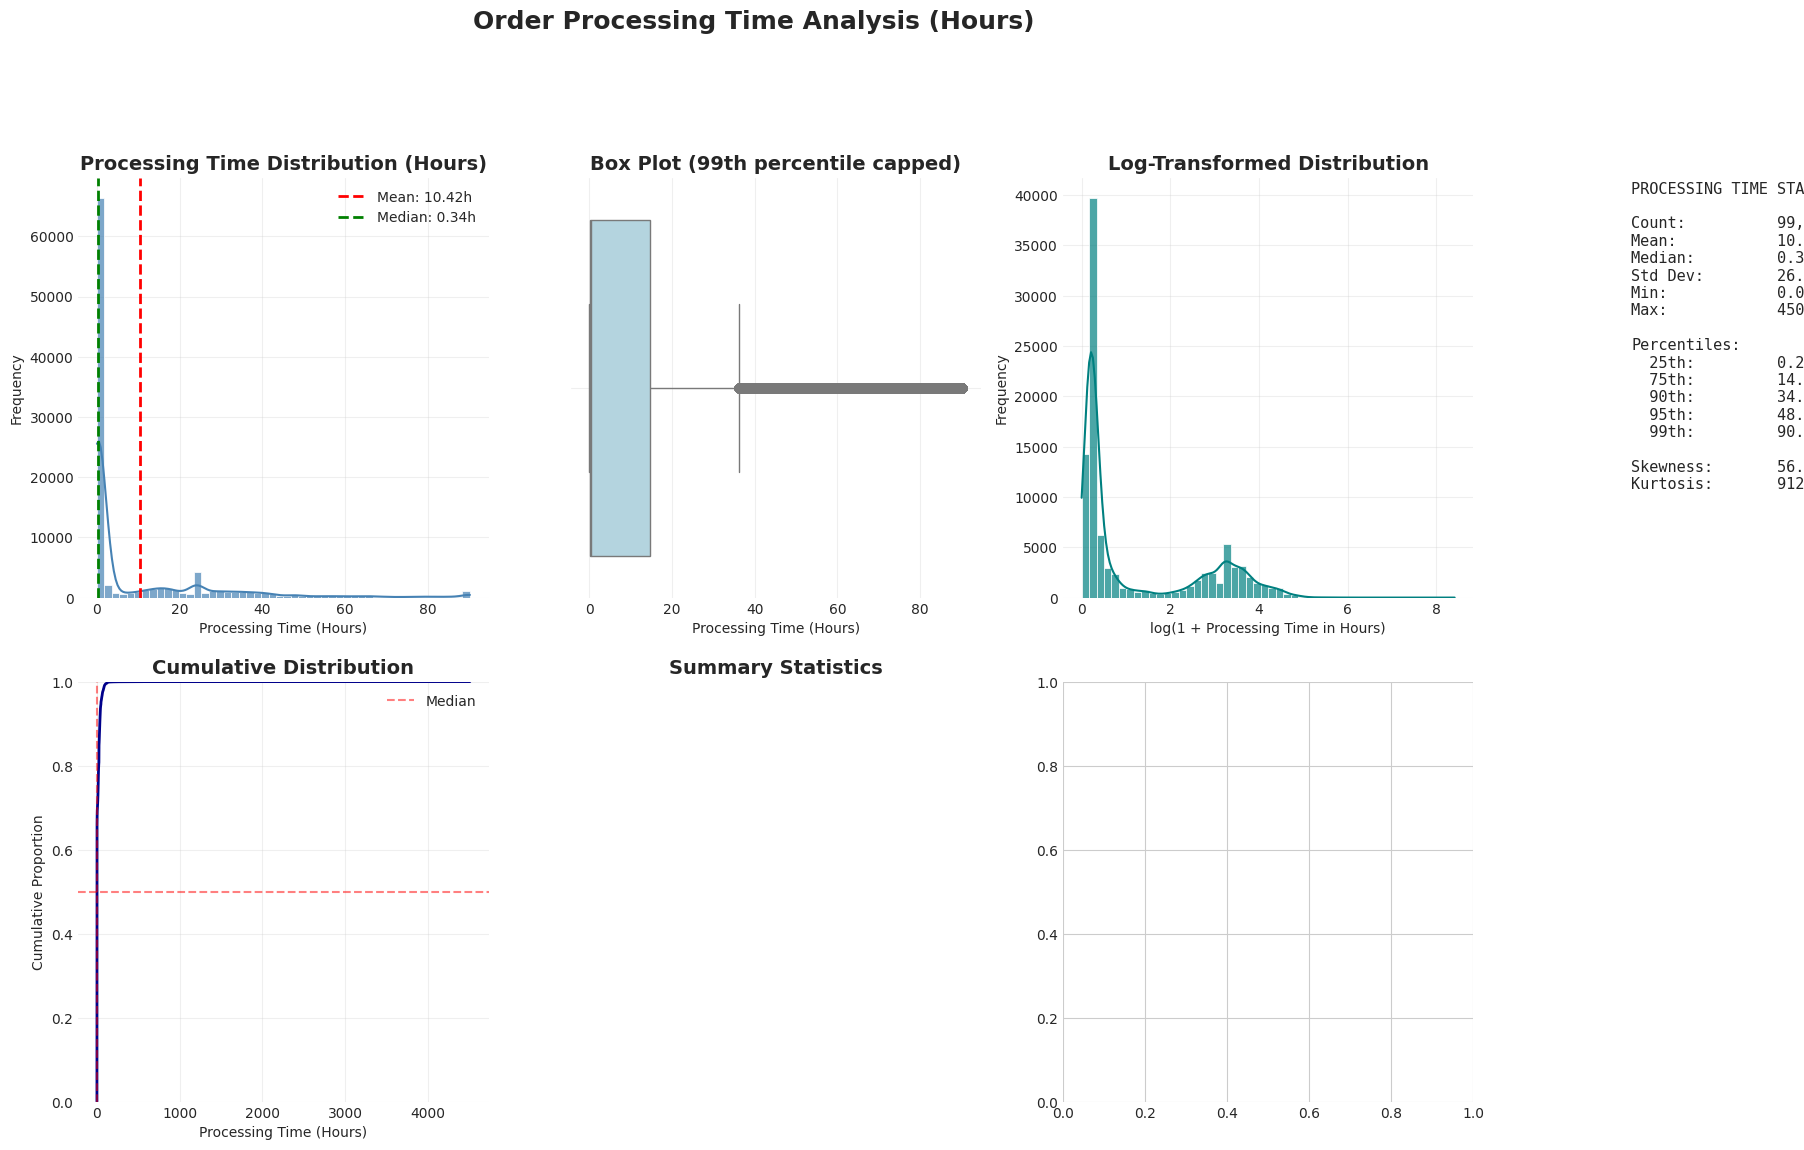

In [34]:
# ============ COMPLETE DISTRIBUTION ANALYSIS ============

print("\n=== ORDER PROCESSING TIME DISTRIBUTION (HOURS) ===")
print("=" * 50)

# Summary statistics
print("\nSummary Statistics:")
print(orders['order_processing_time_hours'].describe())

# Percentiles
percentiles = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
print("\nPercentiles:")
for p in percentiles:
    val = orders['order_processing_time_hours'].quantile(p)
    print(f"  {p*100:5.1f}th percentile: {val:.2f} hours ({val/24:.2f} days)")

# ============ VISUALIZATIONS ============

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Histogram with KDE (Hours)
ax1 = axes[0, 0]
# Cap at 99th percentile for better visualization
capped_hours = orders['order_processing_time_hours'].clip(
    upper=orders['order_processing_time_hours'].quantile(0.99)
)
sns.histplot(capped_hours, bins=50, kde=True, color='steelblue', alpha=0.7, ax=ax1)
ax1.axvline(orders['order_processing_time_hours'].mean(), color='red', linestyle='--',
            linewidth=2, label=f'Mean: {orders["order_processing_time_hours"].mean():.2f}h')
ax1.axvline(orders['order_processing_time_hours'].median(), color='green', linestyle='--',
            linewidth=2, label=f'Median: {orders["order_processing_time_hours"].median():.2f}h')
ax1.set_title('Processing Time Distribution (Hours)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Processing Time (Hours)')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Box Plot
ax2 = axes[0, 1]
sns.boxplot(x=capped_hours, color='lightblue', ax=ax2)
ax2.set_title('Box Plot (99th percentile capped)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Processing Time (Hours)')
ax2.grid(True, alpha=0.3)

# 3. Log-transformed distribution
ax3 = axes[0, 2]
orders['log_processing_hours'] = np.log1p(orders['order_processing_time_hours'])
sns.histplot(orders['log_processing_hours'], bins=50, kde=True, color='teal', alpha=0.7, ax=ax3)
ax3.set_title('Log-Transformed Distribution', fontsize=14, fontweight='bold')
ax3.set_xlabel('log(1 + Processing Time in Hours)')
ax3.set_ylabel('Frequency')
ax3.grid(True, alpha=0.3)

# 4. Cumulative Distribution (ECDF)
ax4 = axes[1, 0]
sns.ecdfplot(orders['order_processing_time_hours'], ax=ax4, color='darkblue', linewidth=2)
ax4.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Median')
ax4.axvline(x=orders['order_processing_time_hours'].median(), color='red', linestyle='--', alpha=0.5)
ax4.set_title('Cumulative Distribution', fontsize=14, fontweight='bold')
ax4.set_xlabel('Processing Time (Hours)')
ax4.set_ylabel('Cumulative Proportion')
ax4.grid(True, alpha=0.3)
ax4.legend()

# 5. Summary Stats Table
ax5 = axes[1, 1]
ax5.axis('off')
stats_text = f"""
PROCESSING TIME STATISTICS (HOURS)

Count:          {len(orders):,}
Mean:           {orders['order_processing_time_hours'].mean():.2f} hours
Median:         {orders['order_processing_time_hours'].median():.2f} hours
Std Dev:        {orders['order_processing_time_hours'].std():.2f} hours
Min:            {orders['order_processing_time_hours'].min():.2f} hours
Max:            {orders['order_processing_time_hours'].max():.2f} hours

Percentiles:
  25th:         {orders['order_processing_time_hours'].quantile(0.25):.2f} hours
  75th:         {orders['order_processing_time_hours'].quantile(0.75):.2f} hours
  90th:         {orders['order_processing_time_hours'].quantile(0.90):.2f} hours
  95th:         {orders['order_processing_time_hours'].quantile(0.95):.2f} hours
  99th:         {orders['order_processing_time_hours'].quantile(0.99):.2f} hours

Skewness:       {orders['order_processing_time_hours'].skew():.4f}
Kurtosis:       {orders['order_processing_time_hours'].kurtosis():.4f}
"""
ax5.text(0.1, 0.95, stats_text, transform=ax6.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace')
ax5.set_title('Summary Statistics', fontsize=14, fontweight='bold')

plt.suptitle('Order Processing Time Analysis (Hours)', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('order_processing_time_hours_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

#What share of total GMV is concentrated in the top 10% of orders by value, and what product categories drive that concentration?

In [35]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [36]:
order_items['GMV']=order_items['price']+order_items['freight_value']


=== GMV CONCENTRATION ANALYSIS ===
Total Orders: 98,666
Total GMV: R$15,843,553.24

Top 10% of Orders: 9,866 orders
Top 10% GMV: R$6,049,381.39
Top 10% Share of Total GMV: 38.18%

CONCENTRATION BY TOP PERCENTILES
Top %  Orders             GMV Share of Total
   1%     986  R$1,654,474.15         10.44%
   5%    4933  R$4,252,453.66         26.84%
  10%    9866  R$6,049,381.39         38.18%
  20%   19733  R$8,448,938.16         53.33%
  30%   29599 R$10,208,329.72         64.43%
  50%   49333 R$12,768,971.88         80.59%

PARETO ANALYSIS (80/20 RULE)
Top 49.1% of orders contribute to 80% of total GMV
Top 20% of orders contribute 53.3% of total GMV


/tmp/ipykernel_874/3535638292.py:129: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_gmv = order_value.groupby('segment')['order_gmv'].sum() / total_gmv * 100


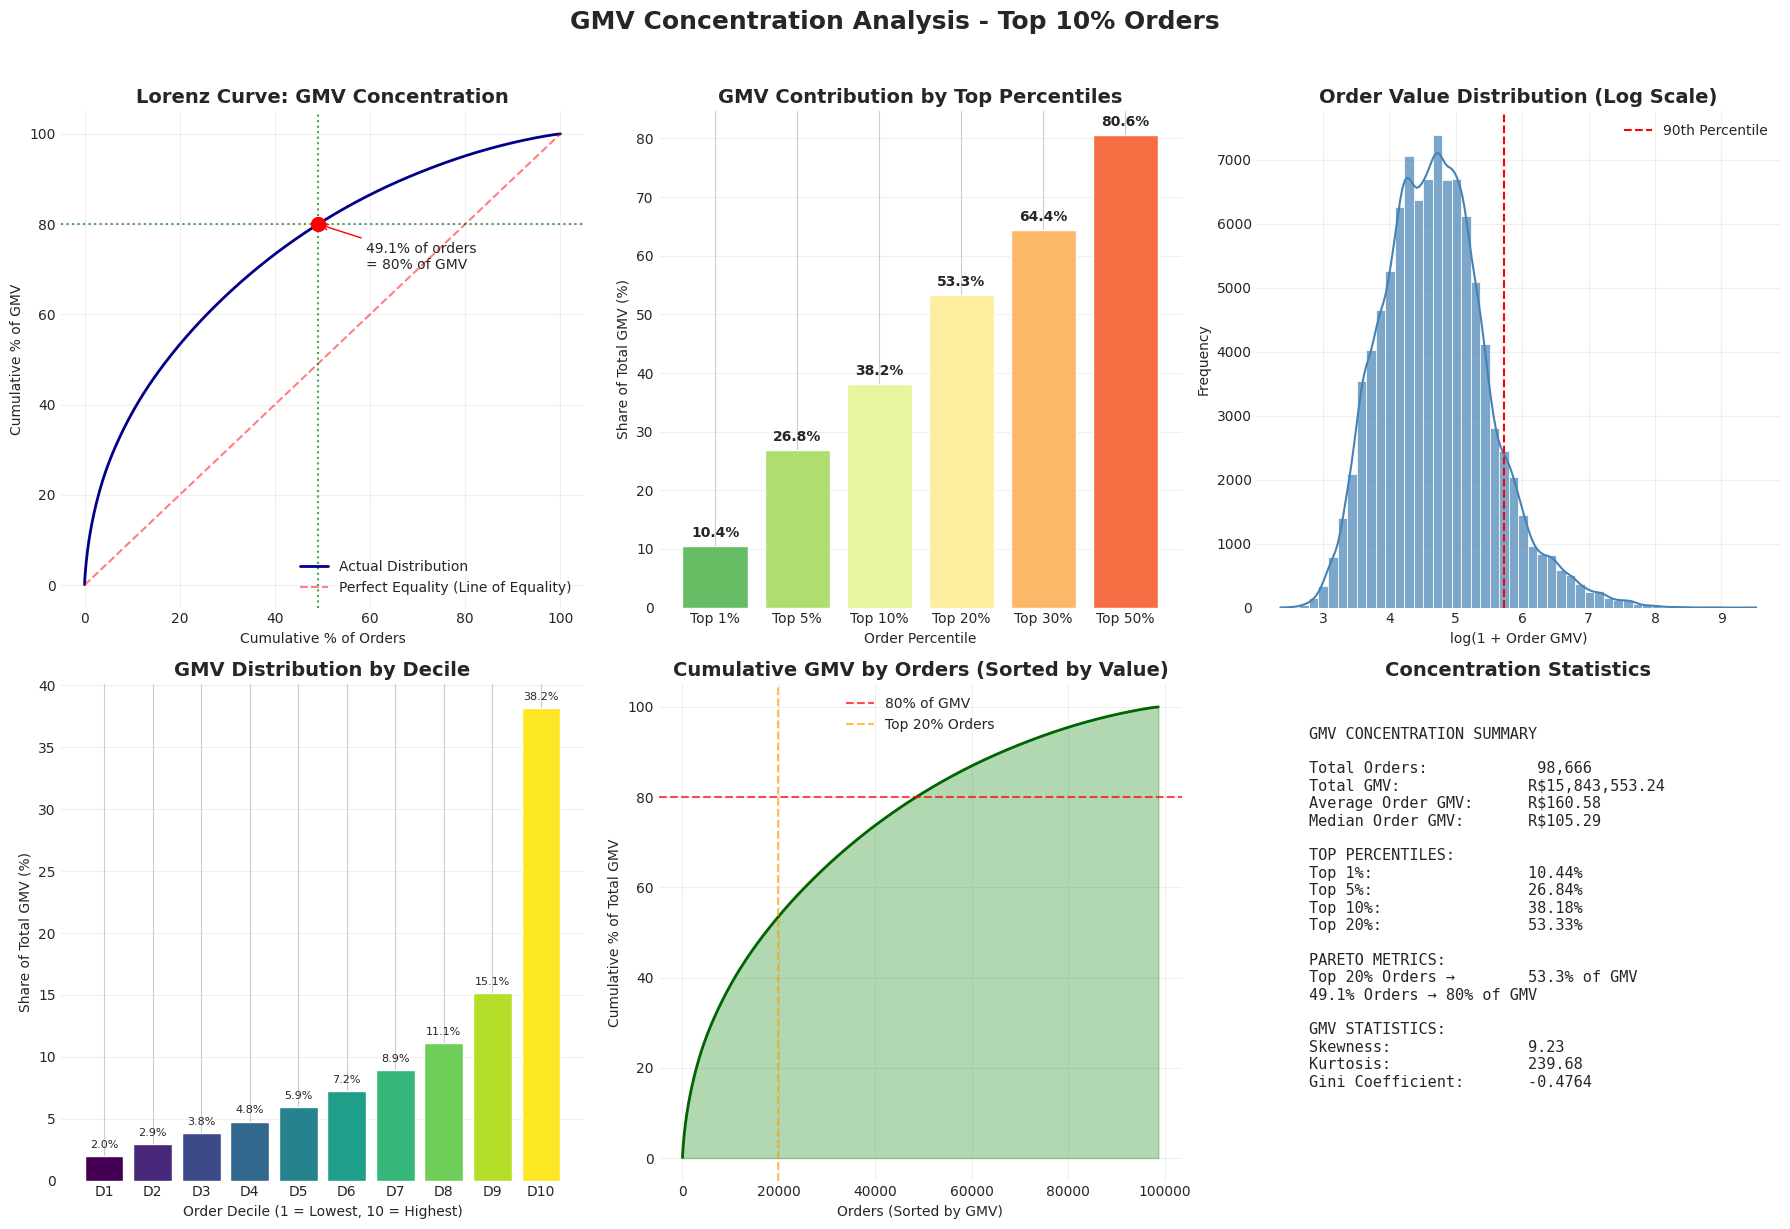

In [38]:
# Calculate order value (GMV) per order
order_value = order_items.groupby('order_id')['GMV'].sum().reset_index()
order_value.columns = ['order_id', 'order_gmv']

# Sort by GMV descending
order_value_sorted = order_value.sort_values('order_gmv', ascending=False)

# ============ 1. CALCULATE TOP 10% CONCENTRATION ============

# Calculate total GMV
total_gmv = order_value['order_gmv'].sum()

# Get top 10% of orders by value
top_10_percent_count = int(len(order_value) * 0.1)
top_10_percent_orders = order_value_sorted.head(top_10_percent_count)
top_10_percent_gmv = top_10_percent_orders['order_gmv'].sum()
top_10_percent_share = (top_10_percent_gmv / total_gmv) * 100

print("=== GMV CONCENTRATION ANALYSIS ===")
print("=" * 50)
print(f"Total Orders: {len(order_value):,}")
print(f"Total GMV: R${total_gmv:,.2f}")
print(f"\nTop 10% of Orders: {top_10_percent_count:,} orders")
print(f"Top 10% GMV: R${top_10_percent_gmv:,.2f}")
print(f"Top 10% Share of Total GMV: {top_10_percent_share:.2f}%")

# ============ 2. MULTIPLE PERCENTILE ANALYSIS ============

print("\n" + "="*50)
print("CONCENTRATION BY TOP PERCENTILES")
print("="*50)

percentiles = [1, 5, 10, 20, 30, 50]
results = []

for pct in percentiles:
    n_orders = int(len(order_value) * (pct / 100))
    top_orders = order_value_sorted.head(n_orders)
    top_gmv = top_orders['order_gmv'].sum()
    share = (top_gmv / total_gmv) * 100
    results.append({
        'Top %': f'{pct}%',
        'Orders': n_orders,
        'GMV': f'R${top_gmv:,.2f}',
        'Share of Total': f'{share:.2f}%'
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# ============ 3. PARETO ANALYSIS (80/20 Rule) ============

print("\n" + "="*50)
print("PARETO ANALYSIS (80/20 RULE)")
print("="*50)

# Calculate cumulative percentage of GMV
order_value_sorted['cumulative_gmv'] = order_value_sorted['order_gmv'].cumsum()
order_value_sorted['cumulative_percentage'] = (order_value_sorted['cumulative_gmv'] / total_gmv) * 100
order_value_sorted['order_percentage'] = (np.arange(1, len(order_value_sorted) + 1) / len(order_value_sorted)) * 100

# Find what percentage of orders contribute to 80% of GMV
pct_orders_for_80 = order_value_sorted[order_value_sorted['cumulative_percentage'] >= 80]['order_percentage'].iloc[0]
print(f"Top {pct_orders_for_80:.1f}% of orders contribute to 80% of total GMV")

# Find what percentage of GMV comes from top 20% of orders
top_20_pct_orders = int(len(order_value) * 0.2)
top_20_gmv = order_value_sorted.head(top_20_pct_orders)['order_gmv'].sum()
top_20_share = (top_20_gmv / total_gmv) * 100
print(f"Top 20% of orders contribute {top_20_share:.1f}% of total GMV")

# ============ 4. VISUALIZATIONS ============

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 4.1 Pareto Chart (Lorenz Curve)
ax1 = axes[0, 0]
# Plot cumulative percentage
ax1.plot(order_value_sorted['order_percentage'],
         order_value_sorted['cumulative_percentage'],
         linewidth=2, color='darkblue', label='Actual Distribution')
# Add diagonal reference line (perfect equality)
ax1.plot([0, 100], [0, 100], 'r--', alpha=0.5, label='Perfect Equality (Line of Equality)')
# Highlight 80/20 point
ax1.axhline(y=80, color='green', linestyle=':', alpha=0.7)
ax1.axvline(x=pct_orders_for_80, color='green', linestyle=':', alpha=0.7)
ax1.scatter(pct_orders_for_80, 80, color='red', s=100, zorder=5)
ax1.annotate(f'{pct_orders_for_80:.1f}% of orders\n= 80% of GMV',
             xy=(pct_orders_for_80, 80), xytext=(pct_orders_for_80+10, 70),
             arrowprops=dict(arrowstyle='->', color='red'))
ax1.set_title('Lorenz Curve: GMV Concentration', fontsize=14, fontweight='bold')
ax1.set_xlabel('Cumulative % of Orders')
ax1.set_ylabel('Cumulative % of GMV')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower right')

# 4.2 Bar Chart - Top Percentiles Contribution
ax2 = axes[0, 1]
pct_labels = [f'Top {p}%' for p in percentiles]
shares = [float(r['Share of Total'].replace('%', '')) for r in results]
bars = ax2.bar(pct_labels, shares, color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(shares))))
ax2.set_title('GMV Contribution by Top Percentiles', fontsize=14, fontweight='bold')
ax2.set_xlabel('Order Percentile')
ax2.set_ylabel('Share of Total GMV (%)')
ax2.grid(True, alpha=0.3, axis='y')
for bar, share in zip(bars, shares):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{share:.1f}%', ha='center', va='bottom', fontweight='bold')

# 4.3 Distribution of Order Values
ax3 = axes[0, 2]
# Log transform for better visualization
log_gmv = np.log1p(order_value['order_gmv'])
sns.histplot(log_gmv, bins=50, kde=True, color='steelblue', alpha=0.7, ax=ax3)
ax3.axvline(np.log1p(order_value['order_gmv'].quantile(0.90)),
            color='red', linestyle='--', label='90th Percentile')
ax3.set_title('Order Value Distribution (Log Scale)', fontsize=14, fontweight='bold')
ax3.set_xlabel('log(1 + Order GMV)')
ax3.set_ylabel('Frequency')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4.4 Box Plot by Segments
ax4 = axes[1, 0]
# Create segments
order_value['segment'] = pd.qcut(order_value['order_gmv'],
                                  q=10,
                                  labels=[f'D{i+1}' for i in range(10)])
segment_gmv = order_value.groupby('segment')['order_gmv'].sum() / total_gmv * 100
segment_gmv = segment_gmv.sort_index()
bars = ax4.bar(segment_gmv.index, segment_gmv.values, color=plt.cm.viridis(np.linspace(0, 1, 10)))
ax4.set_title('GMV Distribution by Decile', fontsize=14, fontweight='bold')
ax4.set_xlabel('Order Decile (1 = Lowest, 10 = Highest)')
ax4.set_ylabel('Share of Total GMV (%)')
ax4.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, segment_gmv.values):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

# 4.5 Cumulative Distribution
ax5 = axes[1, 1]
# Sort and calculate cumulative
order_value_sorted['gmv_share'] = order_value_sorted['order_gmv'] / total_gmv
order_value_sorted['cumulative_gmv_share'] = order_value_sorted['gmv_share'].cumsum()
ax5.plot(range(1, len(order_value_sorted) + 1),
         order_value_sorted['cumulative_gmv_share'] * 100,
         linewidth=2, color='darkgreen')
ax5.fill_between(range(1, len(order_value_sorted) + 1),
                 0, order_value_sorted['cumulative_gmv_share'] * 100,
                 alpha=0.3, color='green')
ax5.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% of GMV')
ax5.axvline(x=top_20_pct_orders, color='orange', linestyle='--', alpha=0.7,
            label=f'Top 20% Orders')
ax5.set_title('Cumulative GMV by Orders (Sorted by Value)', fontsize=14, fontweight='bold')
ax5.set_xlabel('Orders (Sorted by GMV)')
ax5.set_ylabel('Cumulative % of Total GMV')
ax5.grid(True, alpha=0.3)
ax5.legend()

# 4.6 Key Statistics Summary
ax6 = axes[1, 2]
ax6.axis('off')
stats_text = f"""
GMV CONCENTRATION SUMMARY

Total Orders:            {len(order_value):,}
Total GMV:              R${total_gmv:,.2f}
Average Order GMV:      R${order_value['order_gmv'].mean():,.2f}
Median Order GMV:       R${order_value['order_gmv'].median():,.2f}

TOP PERCENTILES:
Top 1%:                 {results[0]['Share of Total']}
Top 5%:                 {results[1]['Share of Total']}
Top 10%:                {results[2]['Share of Total']}
Top 20%:                {results[3]['Share of Total']}

PARETO METRICS:
Top 20% Orders →        {top_20_share:.1f}% of GMV
{pct_orders_for_80:.1f}% Orders → 80% of GMV

GMV STATISTICS:
Skewness:               {order_value['order_gmv'].skew():.2f}
Kurtosis:               {order_value['order_gmv'].kurtosis():.2f}
Gini Coefficient:       {1 - (2 * order_value_sorted['cumulative_gmv_share'].sum() / len(order_value_sorted)):.4f}
"""
ax6.text(0.1, 0.95, stats_text, transform=ax6.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace')
ax6.set_title('Concentration Statistics', fontsize=14, fontweight='bold')

plt.suptitle('GMV Concentration Analysis - Top 10% Orders', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gmv_concentration_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [39]:
order_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,GMV
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04
...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,343.40
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,386.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,116.85
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,64.71


In [40]:
products=pd.read_parquet('products.parquet')

In [42]:
products_translations=pd.read_parquet('product_category_name_translation.parquet')

In [43]:
products_english_categories=products.merge(products_translations, on='product_category_name', how='left')

In [44]:
order_items_english_categories=order_items.merge(products_english_categories, on='product_id', how='left')

In [45]:
order_items_english_categories.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,GMV,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


In [46]:
order_items_english_categories.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0
GMV,0
product_category_name,0
product_name_lenght,1603


In [47]:
order_items_english_categories.product_category_name_english.fillna('unknown',inplace=True)

In [48]:
order_items_english_categories.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0
GMV,0
product_category_name,0
product_name_lenght,1603


In [50]:
order_items_english_categories[order_items_english_categories['product_category_name_english']=='unknown']

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,GMV,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
123,0046e1d57f4c07c8c92ab26be8c3dfc0,1,ff6caf9340512b8bf6d2a2a6df032cfa,38e6dada03429a47197d5d584d793b41,2017-10-02 15:49:17,7.79,7.78,15.57,unknown,NaN,NaN,NaN,200.0,16.0,5.0,12.0,unknown
125,00482f2670787292280e0a8153d82467,1,a9c404971d1a5b1cbc2e4070e02731fd,702835e4b785b67a084280efca355756,2017-02-17 16:18:07,7.60,10.96,18.56,unknown,NaN,NaN,NaN,700.0,35.0,14.0,11.0,unknown
132,004f5d8f238e8908e6864b874eda3391,1,5a848e4ab52fd5445cdc07aab1c40e48,c826c40d7b19f62a09e2d7c5e7295ee2,2018-03-06 09:29:25,122.99,15.61,138.60,unknown,NaN,NaN,NaN,400.0,20.0,12.0,15.0,unknown
142,0057199db02d1a5ef41bacbf41f8f63b,1,41eee23c25f7a574dfaf8d5c151dbb12,e5a3438891c0bfdb9394643f95273d8e,2018-01-25 09:07:51,20.30,16.79,37.09,unknown,NaN,NaN,NaN,200.0,16.0,2.0,11.0,unknown
171,006cb7cafc99b29548d4f412c7f9f493,1,e10758160da97891c2fdcbc35f0f031d,323ce52b5b81df2cd804b017b7f09aa7,2018-02-22 13:35:28,56.00,14.14,70.14,unknown,NaN,NaN,NaN,2200.0,16.0,2.0,11.0,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112306,ff24fec69b7f3d30f9dc1ab3aee7c179,1,5a848e4ab52fd5445cdc07aab1c40e48,c826c40d7b19f62a09e2d7c5e7295ee2,2018-02-01 02:40:12,122.99,15.61,138.60,unknown,NaN,NaN,NaN,400.0,20.0,12.0,15.0,unknown
112333,ff3024474be86400847879103757d1fd,1,f9b1795281ce51b1cf39ef6d101ae8ab,3771c85bac139d2344864ede5d9341e3,2017-11-21 03:55:39,39.90,9.94,49.84,unknown,NaN,NaN,NaN,400.0,32.0,15.0,15.0,unknown
112350,ff3a45ee744a7c1f8096d2e72c1a23e4,1,b61d1388a17e3f547d2bc218df02335b,07017df32dc5f2f1d2801e579548d620,2017-05-10 10:15:19,139.00,21.42,160.42,unknown,NaN,NaN,NaN,350.0,16.0,6.0,11.0,unknown
112438,ff7b636282b98e0aa524264b295ed928,1,431df35e52c10451171d8037482eeb43,6cd68b3ed6d59aaa9fece558ad360c0a,2018-02-22 15:35:35,49.90,15.11,65.01,unknown,NaN,NaN,NaN,475.0,21.0,15.0,21.0,unknown


In [52]:
order_value_categories = order_items_english_categories.groupby(['order_id','product_category_name_english'])['GMV'].sum().reset_index()

In [53]:
order_value_categories

,order_id,product_category_name_english,GMV
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff,72.19
1,00018f77f2f0320c557190d7a144bdd3,pet_shop,259.83
2,000229ec398224ef6ca0657da4fc703e,furniture_decor,216.87
3,00024acbcdf0a6daa1e931b038114c75,perfumery,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools,218.04
...,...,...,...
99465,fffc94f6ce00a00581880bf54a75a037,housewares,343.40
99466,fffcd46ef2263f404302a634eb57f7eb,computers_accessories,386.53
99467,fffce4705a9662cd70adb13d4a31832d,sports_leisure,116.85
99468,fffe18544ffabc95dfada21779c9644f,computers_accessories,64.71


=== TOP 10% ORDERS IDENTIFIED ===
Total Orders: 98,666
Top 10% Orders: 9,866
Total GMV (All Orders): R$15,843,553.24
Top 10% GMV: R$6,049,381.39

TOP CATEGORIES IN TOP 10% ORDERS
             category  gmv_top_10_pct    gmv_all  share_in_top_10  concentration_index  overall_share  concentration_ratio
        watches_gifts       652945.77 1305541.61        50.013402            10.793596       8.245558             6.065496
        health_beauty       646298.52 1441248.07        44.842976            10.683713       9.102655             4.926362
computers_accessories       378048.91 1059272.40        35.689489             6.249381       6.690167             5.334618
       sports_leisure       339209.15 1156656.48        29.326698             5.607336       7.305227             4.014481
                 auto       312586.41  685384.32        45.607464             5.167246       4.328760            10.535919
           cool_stuff       276579.66  719329.95        38.449624             4.572

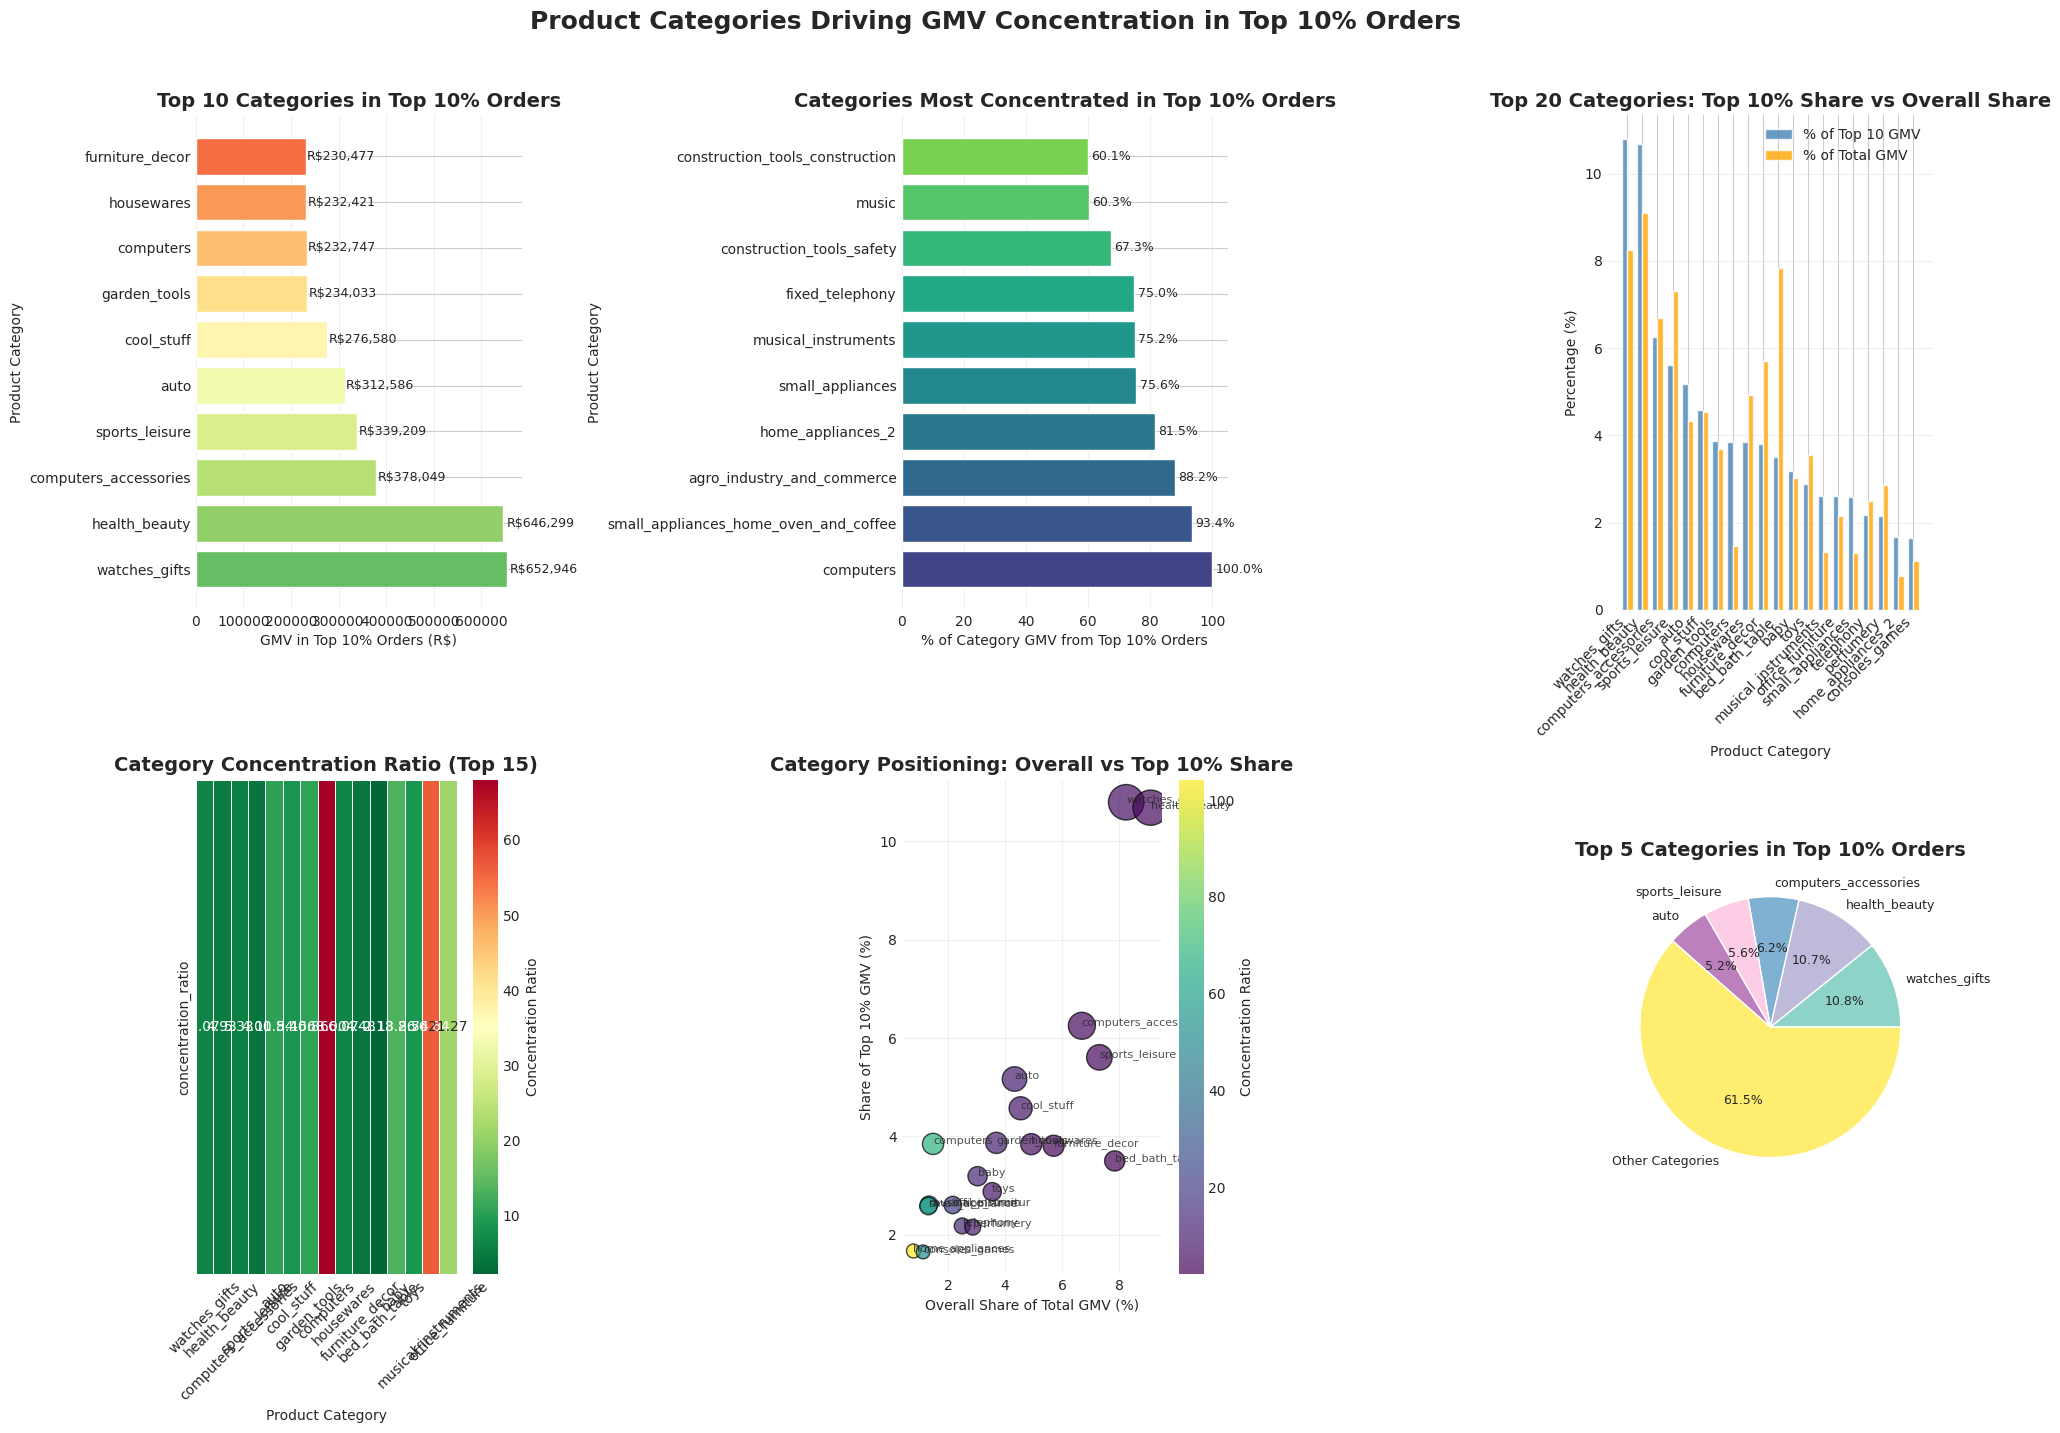

In [54]:

order_value_categories = order_items_english_categories.groupby(
    ['order_id', 'product_category_name_english']
)['GMV'].sum().reset_index()

# ============ 1. CALCULATE ORDER-LEVEL GMV ============

# Total GMV per order (across all categories)
order_total_gmv = order_value_categories.groupby('order_id')['GMV'].sum().reset_index()
order_total_gmv.columns = ['order_id', 'total_gmv']

# Sort to identify top 10% orders
order_total_gmv_sorted = order_total_gmv.sort_values('total_gmv', ascending=False)
top_10_pct_count = int(len(order_total_gmv) * 0.10)
top_10_pct_orders = order_total_gmv_sorted.head(top_10_pct_count)['order_id'].tolist()

print("=== TOP 10% ORDERS IDENTIFIED ===")
print("=" * 50)
print(f"Total Orders: {len(order_total_gmv):,}")
print(f"Top 10% Orders: {top_10_pct_count:,}")
print(f"Total GMV (All Orders): R${order_total_gmv['total_gmv'].sum():,.2f}")
print(f"Top 10% GMV: R${order_total_gmv_sorted.head(top_10_pct_count)['total_gmv'].sum():,.2f}")

# ============ 2. CATEGORY ANALYSIS - TOP 10% ORDERS ============

# Filter for top 10% orders
top_orders_data = order_value_categories[
    order_value_categories['order_id'].isin(top_10_pct_orders)
]

# Category GMV in top 10% orders
category_gmv_top = top_orders_data.groupby('product_category_name_english')['GMV'].sum().reset_index()
category_gmv_top.columns = ['category', 'gmv_top_10_pct']
category_gmv_top = category_gmv_top.sort_values('gmv_top_10_pct', ascending=False)

# Category GMV in all orders (for comparison)
category_gmv_all = order_value_categories.groupby('product_category_name_english')['GMV'].sum().reset_index()
category_gmv_all.columns = ['category', 'gmv_all']
category_gmv_all = category_gmv_all.sort_values('gmv_all', ascending=False)

# Merge for comparison
category_analysis = category_gmv_top.merge(category_gmv_all, on='category', how='left')
category_analysis['share_in_top_10'] = (category_analysis['gmv_top_10_pct'] / category_analysis['gmv_all']) * 100
category_analysis['concentration_index'] = (category_analysis['gmv_top_10_pct'] / category_analysis['gmv_top_10_pct'].sum()) * 100
category_analysis['overall_share'] = (category_analysis['gmv_all'] / category_analysis['gmv_all'].sum()) * 100
category_analysis['concentration_ratio'] = category_analysis['share_in_top_10'] / category_analysis['overall_share']

print("\n" + "="*50)
print("TOP CATEGORIES IN TOP 10% ORDERS")
print("="*50)
print(category_analysis.head(10).to_string(index=False))

# ============ 3. VISUALIZATIONS ============

fig, axes = plt.subplots(2, 3, figsize=(20, 14))

# 3.1 Top Categories by GMV in Top 10% Orders
ax1 = axes[0, 0]
top_categories = category_analysis.head(10)
bars = ax1.barh(top_categories['category'], top_categories['gmv_top_10_pct'],
                color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_categories))))
ax1.set_title('Top 10 Categories in Top 10% Orders', fontsize=14, fontweight='bold')
ax1.set_xlabel('GMV in Top 10% Orders (R$)')
ax1.set_ylabel('Product Category')
ax1.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, top_categories['gmv_top_10_pct']):
    ax1.text(val + val*0.01, bar.get_y() + bar.get_height()/2.,
             f'R${val:,.0f}', ha='left', va='center', fontsize=9)

# 3.2 Share of Category GMV Coming from Top 10% Orders
ax2 = axes[0, 1]
top_concentrated = category_analysis.nlargest(10, 'share_in_top_10')
bars = ax2.barh(top_concentrated['category'], top_concentrated['share_in_top_10'],
                color=plt.cm.viridis(np.linspace(0.2, 0.8, len(top_concentrated))))
ax2.set_title('Categories Most Concentrated in Top 10% Orders', fontsize=14, fontweight='bold')
ax2.set_xlabel('% of Category GMV from Top 10% Orders')
ax2.set_ylabel('Product Category')
ax2.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, top_concentrated['share_in_top_10']):
    ax2.text(val + 1, bar.get_y() + bar.get_height()/2.,
             f'{val:.1f}%', ha='left', va='center', fontsize=9)

# 3.3 Comparison: Top 10% Share vs Overall Share
ax3 = axes[0, 2]
top20_categories = category_analysis.head(20)
x = np.arange(len(top20_categories))
width = 0.35
bars1 = ax3.bar(x - width/2, top20_categories['concentration_index'].head(20),
                width, label='% of Top 10 GMV', color='steelblue', alpha=0.8)
bars2 = ax3.bar(x + width/2, top20_categories['overall_share'].head(20),
                width, label='% of Total GMV', color='orange', alpha=0.8)
ax3.set_xlabel('Product Category')
ax3.set_ylabel('Percentage (%)')
ax3.set_title('Top 20 Categories: Top 10% Share vs Overall Share', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(top20_categories['category'].head(20), rotation=45, ha='right')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 3.4 Concentration Ratio Heatmap (Top Categories)
ax4 = axes[1, 0]
top_categories_heatmap = category_analysis.head(15)[['category', 'concentration_ratio']]
heatmap_data = top_categories_heatmap.set_index('category').T
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn_r',
            cbar_kws={'label': 'Concentration Ratio'}, ax=ax4, linewidths=0.5)
ax4.set_title('Category Concentration Ratio (Top 15)', fontsize=14, fontweight='bold')
ax4.set_xlabel('Product Category')
ax4.set_ylabel('')
ax4.tick_params(axis='x', rotation=45)

# 3.5 Scatter Plot: Overall Share vs Top 10% Share
ax5 = axes[1, 1]
top_categories_scatter = category_analysis.head(20)
scatter = ax5.scatter(top_categories_scatter['overall_share'],
                     top_categories_scatter['concentration_index'],
                     s=top_categories_scatter['gmv_top_10_pct']/1000,
                     c=top_categories_scatter['concentration_ratio'],
                     cmap='viridis', alpha=0.7, edgecolors='black', linewidth=1)
ax5.set_xlabel('Overall Share of Total GMV (%)')
ax5.set_ylabel('Share of Top 10% GMV (%)')
ax5.set_title('Category Positioning: Overall vs Top 10% Share', fontsize=14, fontweight='bold')
ax5.grid(True, alpha=0.3)

# Add category labels
for _, row in top_categories_scatter.iterrows():
    ax5.annotate(row['category'][:15],
                (row['overall_share'], row['concentration_index']),
                fontsize=8, alpha=0.8)

plt.colorbar(scatter, ax=ax5, label='Concentration Ratio')

# 3.6 Top Categories Breakdown (Pie Chart)
ax6 = axes[1, 2]
top5_categories = category_analysis.head(5)
other_gmv = category_analysis['gmv_top_10_pct'].sum() - top5_categories['gmv_top_10_pct'].sum()
pie_data = pd.concat([top5_categories[['category', 'gmv_top_10_pct']],
                      pd.DataFrame({'category': ['Other Categories'],
                                    'gmv_top_10_pct': [other_gmv]})])
colors = plt.cm.Set3(np.linspace(0, 1, len(pie_data)))
wedges, texts, autotexts = ax6.pie(pie_data['gmv_top_10_pct'],
                                    labels=pie_data['category'],
                                    autopct='%1.1f%%',
                                    colors=colors,
                                    textprops={'fontsize': 9})
ax6.set_title('Top 5 Categories in Top 10% Orders', fontsize=14, fontweight='bold')

plt.suptitle('Product Categories Driving GMV Concentration in Top 10% Orders',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('category_gmv_concentration_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()